# Hệ Thống Gợi Ý Phim Trong Machine Learning
## (Movie Recommendation System with Machine Learning)

**Phương pháp:**
- **Collaborative Filtering** — Matrix Factorization (SGD)
- **Content-Based Filtering** — TF-IDF + Cosine Similarity

**Bộ dữ liệu:** MovieLens 20M + TMDB 5000

## Phần 1 — Dữ liệu và Tiền xử lý dữ liệu

| Tập tin | Nguồn | Nội dung | Kích thước |
|---------|-------|----------|------------|
| `movie.csv` | MovieLens [6] | movieId, title, genres | 27,278 phim |
| `rating.csv` | MovieLens [6] | userId, movieId, rating | 20M+ đánh giá |
| `tmdb_5000_movies.csv` | TMDB [7] | genres, keywords | 4,803 phim |
| `tmdb_5000_credits.csv` | TMDB [7] | cast, crew (JSON) | 4,803 phim |

**Quy trình tiền xử lý:**
1. Kết nối MovieLens <-> TMDB qua Text Matching (tên phim)
2. **Iterative K-Core Filtering** [8] (min 50 ratings/phim, 50 ratings/user)
3. Tạo chuỗi Soup cho CBF: genres + keywords + cast + director

In [35]:
import pandas as pd
import numpy as np
import ast
import re
import joblib

print("1. Nạp dữ liệu...")

# Nạp các tệp dữ liệu chính
movies = pd.read_csv('movie.csv')
ratings = pd.read_csv('rating.csv')

# Nạp dữ liệu từ TMDB (The Movie Database)
tmdb_m = pd.read_csv('tmdb_5000_movies.csv')
tmdb_c = pd.read_csv(
    'tmdb_5000_credits.csv',
    sep=',',
    quotechar='"',
    encoding='utf-8',
    on_bad_lines='skip',
    low_memory=False
)

# Chỉ giữ các cột cần thiết từ tmdb_c (thông tin diễn viên/đạo diễn)
tmdb_c = tmdb_c[['movie_id', 'title', 'cast', 'crew']]

# ==========================================
# FIX 1: HÀM PARSE JSON MINH BẠCH (Không nuốt lỗi)
# Hàm an toàn để trích xuất thông tin từ chuỗi JSON (ví dụ: genres, keywords, cast)
# ==========================================
def safe_extract(x, key='name', limit=None):
    if pd.isna(x) or x == '[]': # Kiểm tra nếu dữ liệu rỗng hoặc là chuỗi JSON rỗng
        return []
    try:
        obj = ast.literal_eval(x) # Chuyển đổi chuỗi JSON thành đối tượng Python
        result = [
            str(i.get(key, '')).replace(" ", "").lower() # Lấy giá trị theo key, chuẩn hóa về chữ thường không khoảng trắng
            for i in obj if isinstance(i, dict) # Chỉ xử lý các đối tượng là dictionary
        ]
        return result[:limit] if limit else result # Trả về kết quả, giới hạn nếu có
    except: # Bắt lỗi nếu chuỗi JSON không hợp lệ
        return []

# Hàm để trích xuất tên đạo diễn từ cột 'crew'
def extract_director(x):
    if pd.isna(x) or x == '[]': # Kiểm tra nếu dữ liệu rỗng hoặc là chuỗi JSON rỗng
        return []
    try:
        obj = ast.literal_eval(x) # Chuyển đổi chuỗi JSON thành đối tượng Python
        for i in obj:
            if i.get('job') == 'Director': # Tìm dictionary có 'job' là 'Director'
                return [i.get('name', '').replace(" ", "").lower()] # Trả về tên đạo diễn
        return []
    except:
        return []

print("2. Xử lý metadata...")

# Áp dụng hàm safe_extract để làm sạch các cột genres và keywords từ tmdb_m
tmdb_m['genres_clean'] = tmdb_m['genres'].apply(safe_extract)
tmdb_m['keywords_clean'] = tmdb_m['keywords'].apply(safe_extract)

# Áp dụng hàm safe_extract cho cast (giới hạn 3 diễn viên) và extract_director cho crew
tmdb_c['cast_clean'] = tmdb_c['cast'].apply(lambda x: safe_extract(x, limit=3))
tmdb_c['director_clean'] = tmdb_c['crew'].apply(extract_director)

# SỬA LỖI VALUE ERROR: Đồng nhất kiểu dữ liệu về chuỗi (string) trước khi gộp
tmdb_m['id'] = tmdb_m['id'].astype(str)
tmdb_c['movie_id'] = tmdb_c['movie_id'].astype(str)

# Gộp bảng TMDB Movies và Credits dựa trên ID phim
tmdb = tmdb_m.merge(tmdb_c, left_on='id', right_on='movie_id')

# Đổi tên cột 'title_x' thành 'title_tmdb' để tránh nhầm lẫn
tmdb = tmdb.rename(columns={'title_x': 'title_tmdb'})

# Tạo chuỗi "Soup" cho mô hình Content-Based Filtering (CBF)
# Điền giá trị thiếu bằng chuỗi rỗng để tránh lỗi khi gộp chuỗi
tmdb[['genres_clean','keywords_clean','cast_clean','director_clean']] = \
tmdb[['genres_clean','keywords_clean','cast_clean','director_clean']].fillna('')

tmdb['soup'] = tmdb.apply(
    lambda x: ' '.join(x['keywords_clean']) + ' ' +
              ' '.join(x['cast_clean']) + ' ' +
              ' '.join(x['director_clean']) + ' ' +
              ' '.join(x['genres_clean']),
    axis=1 # Áp dụng hàm cho từng hàng của DataFrame
)

# ==========================================
# FIX 2: KẾT NỐI BẰNG TÊN PHIM (ĐÃ SỬA LỖI KEYERROR)
# Hàm làm sạch tiêu đề phim từ MovieLens để khớp với TMDB
# ==========================================
def clean_movielens_title(title):
    if pd.isna(title): return ""
    # Loại bỏ năm phát hành trong dấu ngoặc đơn ở cuối tiêu đề
    title = re.sub(r'\s*\(\d{4}\)\s*$', '', str(title))
    # Xử lý các trường hợp 'The, A' ở cuối tiêu đề (ví dụ: "Lion King, The" -> "The Lion King")
    if title.endswith(', The'):
        title = 'The ' + title[:-5]
    elif title.endswith(', A'):
        title = 'A ' + title[:-3]
    return title.strip().lower() # Chuẩn hóa về chữ thường và loại bỏ khoảng trắng thừa

# Hàm làm sạch tiêu đề phim từ TMDB
def clean_tmdb_title(title):
    return str(title).strip().lower() if pd.notna(title) else "" # Chuẩn hóa về chữ thường và loại bỏ khoảng trắng thừa

# Tạo cột 'match_title' đã làm sạch cho cả hai DataFrame
movies['match_title'] = movies['title'].apply(clean_movielens_title)
tmdb['match_title'] = tmdb['title_tmdb'].apply(clean_tmdb_title)

# Gộp dữ liệu MovieLens và TMDB dựa trên tiêu đề phim đã làm sạch
final_metadata = movies.merge(tmdb, on='match_title', how='inner')
# Loại bỏ các bản sao dựa trên 'movieId' của MovieLens
final_metadata = final_metadata.drop_duplicates(subset=['movieId'])

# Reset lại index để đảm bảo tính liên tục
final_metadata = final_metadata.reset_index(drop=True)

# Tạo một ID mới liên tục ('movie_idx') cho các phim đã được đồng bộ
final_metadata['movie_idx'] = final_metadata.index + 1


print("Match:", len(final_metadata), "/", len(movies))

print(f"- Số lượng phim trong MovieLens: {movies.shape[0]:,}")
print(f"- Số lượng phim trong TMDB: {tmdb.shape[0]:,}")
print(f"- Số lượng phim kết nối THÀNH CÔNG: {final_metadata.shape[0]:,} phim.")
# Lưu ý: Từ giờ hệ thống thống nhất sử dụng 'movieId' của MovieLens làm ID lõi.

# ==========================================
# FIX 3: LỌC DỮ LIỆU THƯA BẰNG VÒNG LẶP (Iterative K-Core)
# Hàm thực hiện lọc K-Core để loại bỏ người dùng và phim có ít tương tác
# ==========================================
def iterative_k_core(ratings_df, min_movie=50, min_user=50):
    print("\n4. Đang chạy thuật toán Lọc dữ liệu thưa (Iterative K-Core)...")
    print(f"- Kích thước ban đầu: {ratings_df.shape[0]:,} đánh giá")
    iteration = 1

    while True:
        start_shape = ratings_df.shape[0] # Lưu lại số lượng đánh giá ban đầu của vòng lặp

        # 1. Lọc phim: Giữ lại phim có ít nhất `min_movie` lượt đánh giá
        movie_counts = ratings_df['movieId'].value_counts()
        valid_movies = movie_counts[movie_counts >= min_movie].index
        ratings_df = ratings_df[ratings_df['movieId'].isin(valid_movies)]

        # 2. Lọc user: Giữ lại người dùng có ít nhất `min_user` lượt đánh giá
        user_counts = ratings_df['userId'].value_counts()
        valid_users = user_counts[user_counts >= min_user].index
        ratings_df = ratings_df[ratings_df['userId'].isin(valid_users)]

        end_shape = ratings_df.shape[0] # Lưu lại số lượng đánh giá sau khi lọc
        print(f"  + Vòng {iteration}: Còn lại {end_shape:,} đánh giá")

        # Nếu số lượng đánh giá không thay đổi, quá trình lọc đã hội tụ
        if start_shape == end_shape:
            print("- Dữ liệu đã hội tụ thành công!")
            break
        iteration += 1

    return ratings_df

# Lọc các đánh giá chỉ cho những phim đã được đồng bộ metadata
ratings_synced = ratings[ratings['movieId'].isin(final_metadata['movieId'])]

# Áp dụng thuật toán lọc K-Core
ratings_filtered = iterative_k_core(ratings_synced, min_movie=50, min_user=50)

print("\n" + "="*50)
print(" TIỀN XỬ LÝ HOÀN TẤT")
print(f" Tổng số User giữ lại: {ratings_filtered['userId'].nunique():,}")
print(f" Tổng số Phim giữ lại: {ratings_filtered['movieId'].nunique():,}")
print(f" Tổng số Đánh giá: {ratings_filtered.shape[0]:,}")
print("="*50)

1. Nạp dữ liệu...
2. Xử lý metadata...
Match: 4364 / 27278
- Số lượng phim trong MovieLens: 27,278
- Số lượng phim trong TMDB: 4,803
- Số lượng phim kết nối THÀNH CÔNG: 4,364 phim.

4. Đang chạy thuật toán Lọc dữ liệu thưa (Iterative K-Core)...
- Kích thước ban đầu: 669,271 đánh giá
  + Vòng 1: Còn lại 536,586 đánh giá
  + Vòng 2: Còn lại 533,465 đánh giá
  + Vòng 3: Còn lại 533,319 đánh giá
  + Vòng 4: Còn lại 533,319 đánh giá
- Dữ liệu đã hội tụ thành công!

 TIỀN XỬ LÝ HOÀN TẤT
 Tổng số User giữ lại: 3,310
 Tổng số Phim giữ lại: 1,752
 Tổng số Đánh giá: 533,319


### 1A — Tổng Quan Nguồn Dữ Liệu & Quyết Định Cột

Hệ thống sử dụng **4 file CSV** từ hai nguồn:

####  MovieLens 20M
| Cột | Kiểu | Giữ lại? | Lý do |
|-----|------|----------|-------|
| `userId` | int |  **Giữ** | ID người dùng — khóa chính cho CF |
| `movieId` | int |  **Giữ** | ID phim — khóa chính kết nối |
| `rating` | float |  **Giữ** | Nhãn mục tiêu (0.5–5.0) cho CF |
| `timestamp` | int |  **Bỏ** | Không dùng trong mô hình hiện tại |

####  TMDB 5000
| File | Cột được dùng | Cột bỏ đi |
|------|--------------|-----------|
| `tmdb_5000_movies.csv` | `id`, `title`, `genres`, `keywords` | Tất cả các cột còn lại |
| `tmdb_5000_credits.csv` | `movie_id`, `cast` (top-3), `crew` (Director) | Tất cả các cột còn lại |

####  Bảng kết hợp cuối — `final_metadata`
| Cột | Nguồn | Vai trò |
|-----|-------|---------|
| `movieId` | MovieLens | Khóa chính |
| `title` | MovieLens | Hiển thị |
| `genres_clean` | TMDB movies | Thể loại (list) |
| `keywords_clean` | TMDB movies | Từ khóa (list) |
| `cast_clean` | TMDB credits | 3 diễn viên chính (list) |
| `director_clean` | TMDB credits | Đạo diễn (list) |
| `soup` | Tổng hợp | Chuỗi văn bản cho CBF |


### 1B — Kết Nối Dữ Liệu: MovieLens ↔ TMDB

**Vấn đề:** MovieLens và TMDB dùng ID phim khác nhau — không thể JOIN trực tiếp.

**Giải pháp:** Kết nối qua **tên phim** sau khi chuẩn hóa:

```
MovieLens title        →  clean_movielens_title()  →  "inception"
TMDB title_tmdb        →  clean_tmdb_title()        →  "inception"
          ↓                                                 ↓
                     INNER JOIN on match_title
```

**Hàm chuẩn hóa:**
- `clean_movielens_title()`: Bỏ năm `(1994)`, xử lý "The, A" ở cuối → `"The Lion King"`
- `clean_tmdb_title()`: Chuyển thường, bỏ khoảng trắng thừa

**Kết quả kết nối:** ~4,364 / 27,278 phim MovieLens khớp với TMDB (chỉ phim có metadata phong phú).


### 1C — Lọc Dữ Liệu Thưa: Iterative K-Core Filtering [8]

**Vấn đề:** Ma trận User-Item rất thưa (~90% rỗng) → MF-SGD không ổn định.

**Thuật toán Iterative K-Core:**
```
Lặp cho đến khi dữ liệu ổn định:
  1. Bỏ phim có < 50 lượt đánh giá
  2. Bỏ user có < 50 lượt đánh giá
```

**Tại sao lặp?** Sau khi bỏ phim → một số user mất đi ratings → có thể rơi dưới ngưỡng 50.
Lặp đảm bảo **tính chất K-Core**: mọi user còn lại đều đã đánh giá ≥50 phim còn lại.

**Kết quả sau lọc:**
| Chỉ số | Trước lọc | Sau lọc |
|--------|-----------|---------|
| Ratings | 669,271 | 533,319 |
| Users | ~138,000 | **3,310** |
| Movies | ~27,278 | **1,752** |
| Sparsity | ~99.9% | **~90.8%** |

>  Tập dữ liệu còn lại **dày đặc hơn** → huấn luyện ổn định hơn.


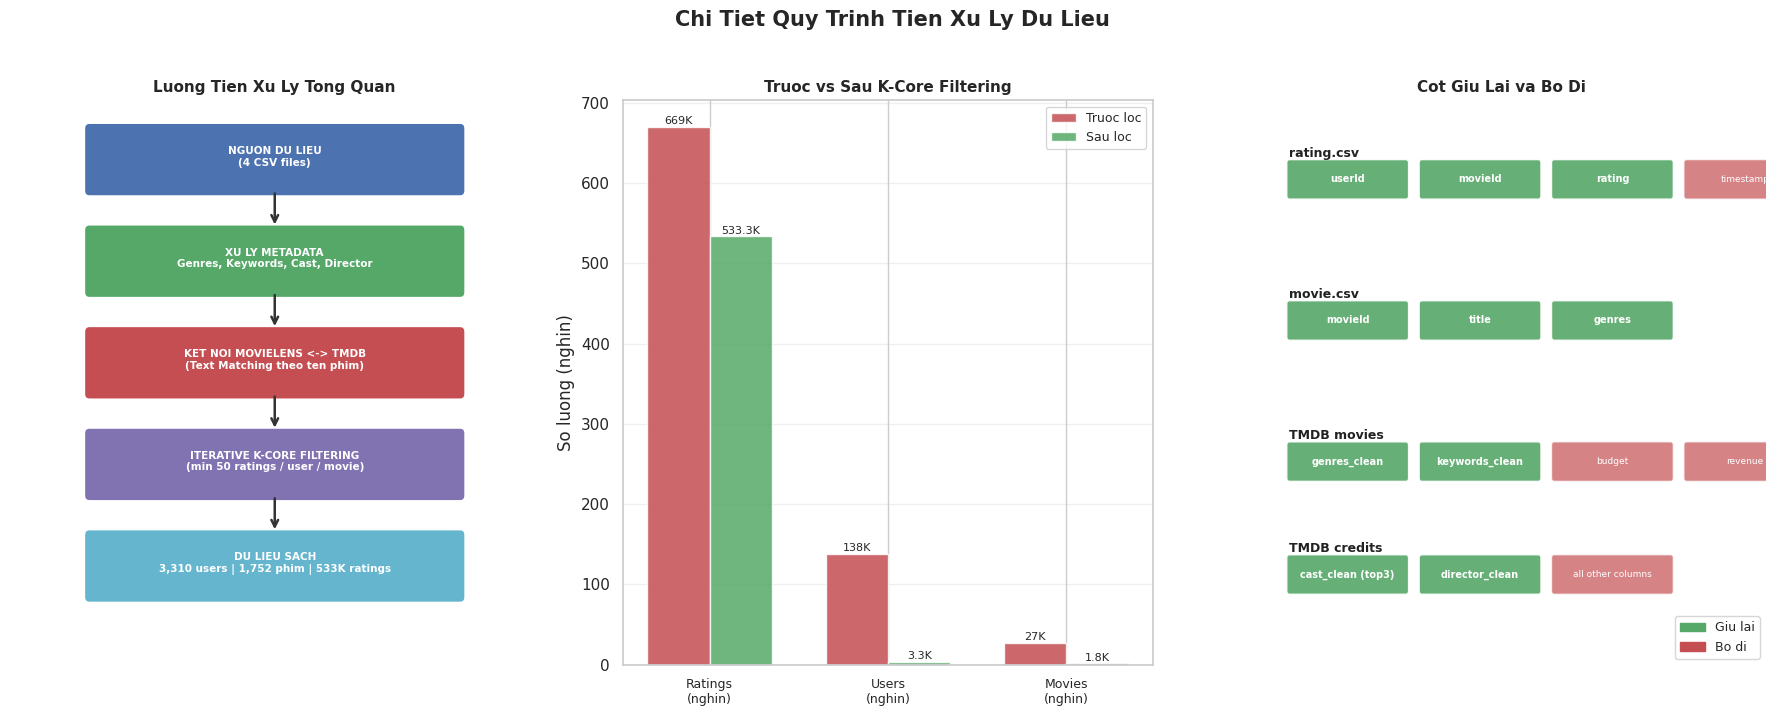

In [36]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

fig, axes = plt.subplots(1, 3, figsize=(18, 7))
fig.suptitle('Chi Tiet Quy Trinh Tien Xu Ly Du Lieu', fontsize=15, fontweight='bold', y=1.02)

# ===================== SUBPLOT 1: Luong tien xu ly =====================
ax = axes[0]
ax.set_xlim(0, 10); ax.set_ylim(0, 10); ax.axis('off')
ax.set_title('Luong Tien Xu Ly Tong Quan', fontweight='bold', fontsize=11)

boxes = [
    (5, 9.0, 'NGUON DU LIEU\n(4 CSV files)', '#4C72B0', 'white'),
    (5, 7.2, 'XU LY METADATA\nGenres, Keywords, Cast, Director', '#55A868', 'white'),
    (5, 5.4, 'KET NOI MOVIELENS <-> TMDB\n(Text Matching theo ten phim)', '#C44E52', 'white'),
    (5, 3.6, 'ITERATIVE K-CORE FILTERING\n(min 50 ratings / user / movie)', '#8172B2', 'white'),
    (5, 1.8, 'DU LIEU SACH\n3,310 users | 1,752 phim | 533K ratings', '#64B5CD', 'white'),
]

for (x, y, txt, color, fg) in boxes:
    ax.add_patch(mpatches.FancyBboxPatch((x-3.5, y-0.6), 7, 1.1,
        boxstyle='round,pad=0.1', fc=color, ec='white', lw=1.5, zorder=2))
    ax.text(x, y, txt, ha='center', va='center', fontsize=7.5,
            color=fg, fontweight='bold', zorder=3, wrap=True)

for i in range(len(boxes)-1):
    ax.annotate('', xy=(5, boxes[i+1][1]+0.55), xytext=(5, boxes[i][1]-0.6),
                arrowprops=dict(arrowstyle='->', color='#333333', lw=1.8))

# ===================== SUBPLOT 2: Truoc / Sau K-Core =====================
ax2 = axes[1]
ax2.set_title('Truoc vs Sau K-Core Filtering', fontweight='bold', fontsize=11)

categories = ['Ratings\n(nghin)', 'Users\n(nghin)', 'Movies\n(nghin)']
before = [669.271, 138.0, 27.278]
after  = [533.319, 3.310, 1.752]

x = [0, 1, 2]
w = 0.35
bars1 = ax2.bar([xi - w/2 for xi in x], before, w, label='Truoc loc', color='#C44E52', alpha=0.85)
bars2 = ax2.bar([xi + w/2 for xi in x], after,  w, label='Sau loc',  color='#55A868', alpha=0.85)

ax2.set_xticks(x); ax2.set_xticklabels(categories, fontsize=9)
ax2.set_ylabel('So luong (nghin)'); ax2.legend(fontsize=9)
ax2.grid(axis='y', alpha=0.3)

for b in bars1:
    ax2.text(b.get_x()+b.get_width()/2, b.get_height()+1,
             f'{b.get_height():.0f}K', ha='center', va='bottom', fontsize=8)
for b in bars2:
    ax2.text(b.get_x()+b.get_width()/2, b.get_height()+1,
             f'{b.get_height():.1f}K', ha='center', va='bottom', fontsize=8)

# ===================== SUBPLOT 3: Cot giu lai / bo di =====================
ax3 = axes[2]
ax3.set_xlim(0, 10); ax3.set_ylim(0, 10); ax3.axis('off')
ax3.set_title('Cot Giu Lai va Bo Di', fontweight='bold', fontsize=11)

keep_color = '#55A868'
drop_color = '#C44E52'

rows = [
    # (y, label, kept_cols, dropped_cols)
    (8.5, 'rating.csv', ['userId', 'movieId', 'rating'], ['timestamp']),
    (6.0, 'movie.csv',  ['movieId', 'title', 'genres'], []),
    (3.5, 'TMDB movies', ['genres_clean', 'keywords_clean'], ['budget','revenue','...']),
    (1.5, 'TMDB credits', ['cast_clean (top3)', 'director_clean'], ['all other columns']),
]

for (y, label, kept, dropped) in rows:
    ax3.text(1.0, y+0.5, label, fontsize=9, fontweight='bold', color='#222222')
    for i, col in enumerate(kept):
        ax3.add_patch(mpatches.FancyBboxPatch((1.0 + i*2.5, y-0.2), 2.2, 0.6,
            boxstyle='round,pad=0.05', fc=keep_color, ec='white', lw=1, alpha=0.9))
        ax3.text(1.0 + i*2.5 + 1.1, y+0.1, col, ha='center', va='center',
                 fontsize=7, color='white', fontweight='bold')
    for i, col in enumerate(dropped):
        xoff = 1.0 + (len(kept) + i)*2.5
        if xoff < 9.5:
            ax3.add_patch(mpatches.FancyBboxPatch((xoff, y-0.2), 2.2, 0.6,
                boxstyle='round,pad=0.05', fc=drop_color, ec='white', lw=1, alpha=0.7))
            ax3.text(xoff + 1.1, y+0.1, col, ha='center', va='center',
                     fontsize=6.5, color='white')

keep_patch = mpatches.Patch(color=keep_color, label='Giu lai')
drop_patch = mpatches.Patch(color=drop_color, label='Bo di')
ax3.legend(handles=[keep_patch, drop_patch], loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()



In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

print('=== THONG KE KET NOI MOVIELENS <-> TMDB ===')
print(f'Tong phim MovieLens : {movies.shape[0]:>8,}')
print(f'Tong phim TMDB      : {tmdb_m.shape[0]:>8,}')
print(f'Ket noi thanh cong  : {final_metadata.shape[0]:>8,}')
print(f'Ti le ket noi       : {final_metadata.shape[0]/movies.shape[0]*100:>7.1f}%')
print()

# Cot trong final_metadata
print('=== CAC COT TRONG final_metadata ===')
for col in final_metadata.columns:
    dtype = str(final_metadata[col].dtype)
    nulls = final_metadata[col].isna().sum()
    print(f'  {col:<25} dtype={dtype:<10} nulls={nulls}')

print()

# Phan tich Soup
soup_sample = final_metadata[final_metadata['soup'].notna()]['soup'].iloc[0]
print('=== VI DU SOUP (phim dau tien) ===')
title_col = next((c for c in ['title','title_x','title_tmdb'] if c in final_metadata.columns), None)
if title_col:
    print(f'Phim: {final_metadata.iloc[0][title_col]}')
print(f'Soup: {soup_sample[:200]}...')


=== THONG KE KET NOI MOVIELENS <-> TMDB ===
Tong phim MovieLens :   27,278
Tong phim TMDB      :    4,803
Ket noi thanh cong  :    4,364
Ti le ket noi       :    16.0%

=== CAC COT TRONG final_metadata ===
  movieId                   dtype=int64      nulls=0
  title                     dtype=str        nulls=0
  genres_x                  dtype=str        nulls=0
  match_title               dtype=str        nulls=0
  budget                    dtype=int64      nulls=0
  genres_y                  dtype=str        nulls=0
  homepage                  dtype=str        nulls=2845
  id                        dtype=str        nulls=0
  keywords                  dtype=str        nulls=0
  original_language         dtype=str        nulls=0
  original_title            dtype=str        nulls=0
  overview                  dtype=str        nulls=0
  popularity                dtype=float64    nulls=0
  production_companies      dtype=str        nulls=0
  production_countries      dtype=str        null

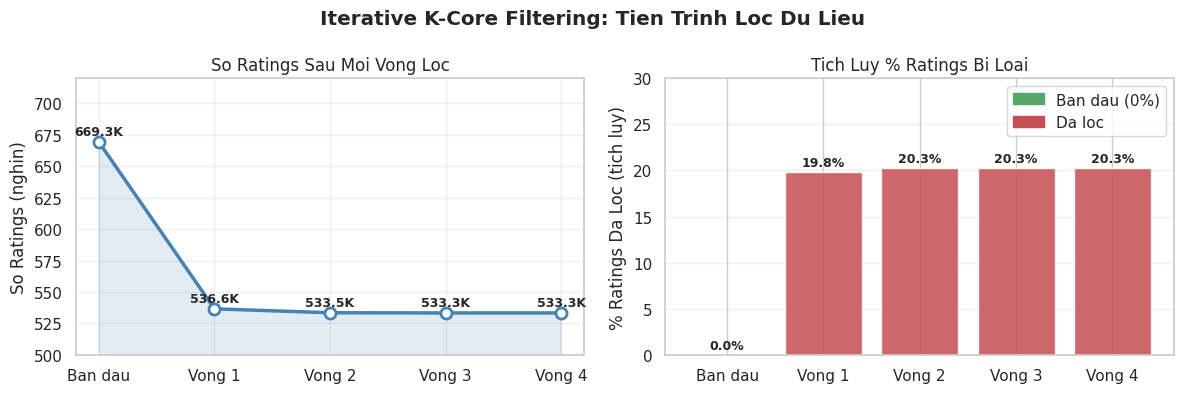

K-Core visualization hoan thanh.
Ket qua: Giu lai 533,319 ratings (79.7% so voi ban dau)
         Loai bo 135,952 ratings (20.3%)


In [38]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

# Du lieu tu output o cell tren (tien xu ly chinh)
kcore_rounds = [669271, 536586, 533465, 533319, 533319]
rounds = list(range(len(kcore_rounds)))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Iterative K-Core Filtering: Tien Trinh Loc Du Lieu', fontweight='bold')

# Subplot 1: So ratings qua tung vong
ax1.plot(rounds, [v/1000 for v in kcore_rounds], 'o-',
         color='steelblue', linewidth=2.5, markersize=8, markerfacecolor='white', markeredgewidth=2)
ax1.fill_between(rounds, [v/1000 for v in kcore_rounds], alpha=0.15, color='steelblue')
for i, v in enumerate(kcore_rounds):
    ax1.text(i, v/1000 + 3, f'{v/1000:.1f}K', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax1.set_xticks(rounds)
ax1.set_xticklabels([f'Vong {i}' if i > 0 else 'Ban dau' for i in rounds])
ax1.set_ylabel('So Ratings (nghin)')
ax1.set_title('So Ratings Sau Moi Vong Loc')
ax1.grid(alpha=0.3)
ax1.set_ylim(500000/1000, 720000/1000)

# Subplot 2: % du lieu bi loai
dropped_pct = [(kcore_rounds[0] - v) / kcore_rounds[0] * 100 for v in kcore_rounds]
colors = ['#C44E52' if i > 0 else '#55A868' for i in range(len(rounds))]
ax2.bar(rounds, dropped_pct, color=colors, alpha=0.85)
for i, v in enumerate(dropped_pct):
    ax2.text(i, v + 0.3, f'{v:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax2.set_xticks(rounds)
ax2.set_xticklabels([f'Vong {i}' if i > 0 else 'Ban dau' for i in rounds])
ax2.set_ylabel('% Ratings Da Loc (tich luy)')
ax2.set_title('Tich Luy % Ratings Bi Loai')
ax2.grid(axis='y', alpha=0.3)
ax2.set_ylim(0, 30)

import matplotlib.patches as mpatches
kept_p = mpatches.Patch(color='#55A868', label='Ban dau (0%)')
drop_p = mpatches.Patch(color='#C44E52', label='Da loc')
ax2.legend(handles=[kept_p, drop_p])

plt.tight_layout()
plt.show()
print('K-Core visualization hoan thanh.')
print(f'Ket qua: Giu lai {533319:,} ratings ({533319/669271*100:.1f}% so voi ban dau)')
print(f'         Loai bo {669271-533319:,} ratings ({(669271-533319)/669271*100:.1f}%)')


## Phần 2 — Khám phá dữ liệu (EDA)

Phân tích đặc điểm bộ dữ liệu trước khi huấn luyện:
- **Phân phối rating**: Xu hướng đánh giá của người dùng
- **Hoạt động user**: Số lượt đánh giá mỗi user
- **Độ thừa (Sparsity)**: Ma trận User-Item thừa đến mức nào?
- **Độ phổ biến phim**: Bao nhiêu phim ít đánh giá?

=== EDA: EXPLORATORY DATA ANALYSIS ===
Users  : 3,310
Movies : 1,752
Ratings: 533,319
Matrix sparsity: 90.80%


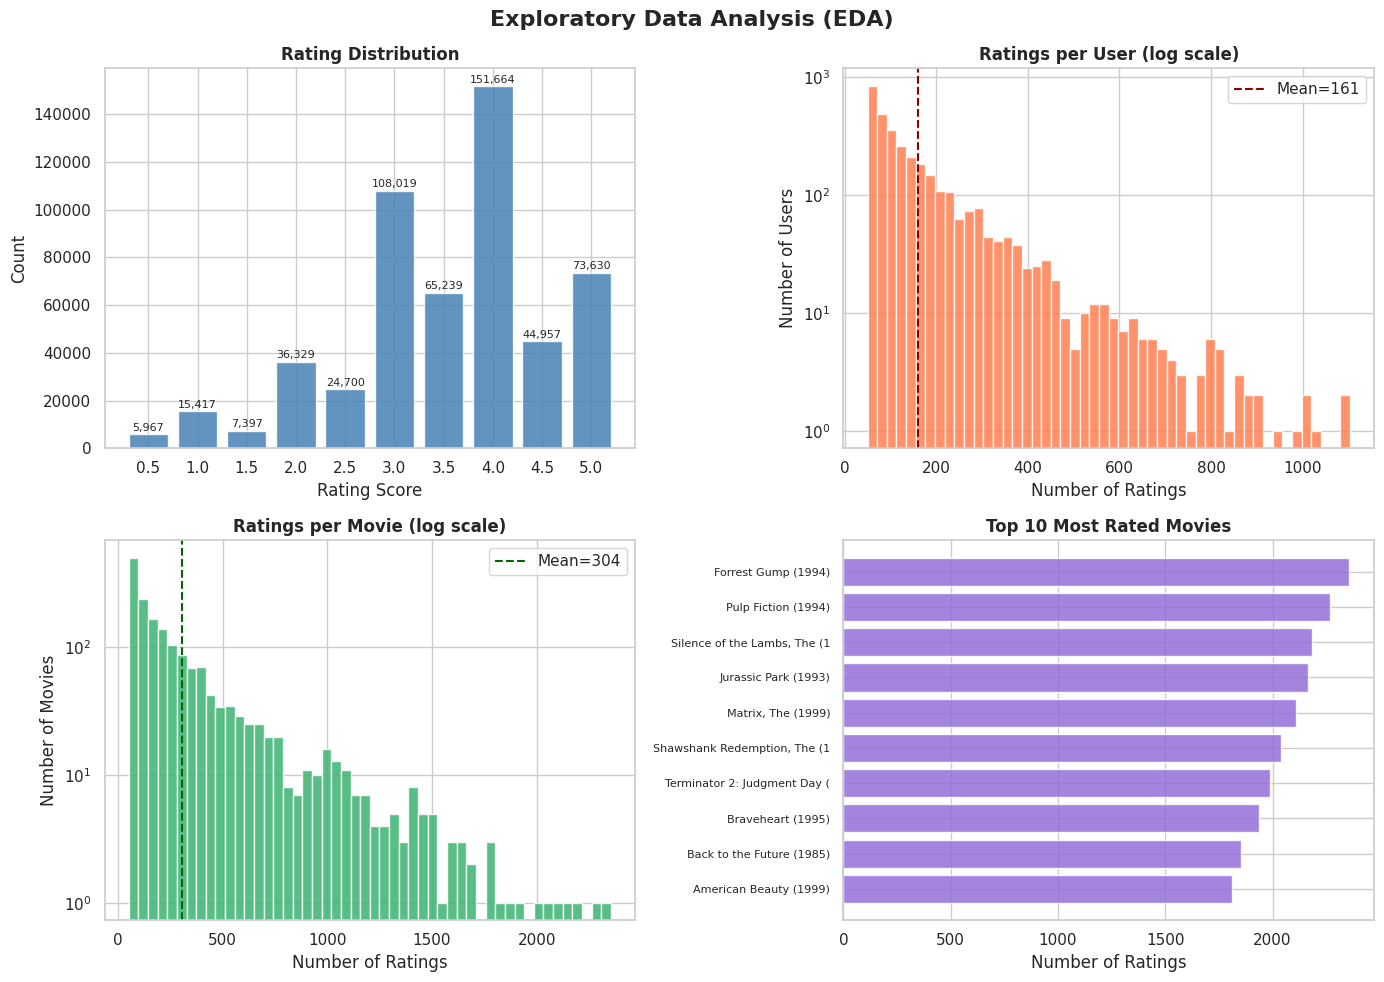

-> Sparsity 90.8%: hầu hết người dùng chỉ đánh giá một phần nhỏ trong tổng số phim.
   Điều này thúc đẩy việc sử dụng Phân tích ma trận thay vì thuật toán CF dựa trên bộ nhớ đơn giản.


In [39]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print('=== EDA: EXPLORATORY DATA ANALYSIS ===')
n_users   = ratings_filtered['userId'].nunique()
n_movies  = ratings_filtered['movieId'].nunique()
n_ratings = ratings_filtered.shape[0]
sparsity  = (1 - n_ratings / (n_users * n_movies)) * 100

print(f'Users  : {n_users:,}')
print(f'Movies : {n_movies:,}')
print(f'Ratings: {n_ratings:,}')
print(f'Matrix sparsity: {sparsity:.2f}%')

user_activity    = ratings_filtered.groupby('userId').size()
movie_popularity = ratings_filtered.groupby('movieId').size()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Exploratory Data Analysis (EDA)', fontsize=16, fontweight='bold')

# 1. Rating distribution
ax1 = axes[0, 0]
rc = ratings_filtered['rating'].value_counts().sort_index()
ax1.bar(rc.index.astype(str), rc.values, color='steelblue', alpha=0.85)
ax1.set_title('Rating Distribution', fontweight='bold')
ax1.set_xlabel('Rating Score'); ax1.set_ylabel('Count')
for p, v in zip(ax1.patches, rc.values):
    ax1.text(p.get_x()+p.get_width()/2, p.get_height()+500,
             f'{v:,}', ha='center', va='bottom', fontsize=8)

# 2. User activity
ax2 = axes[0, 1]
ax2.hist(user_activity, bins=50, color='coral', alpha=0.85)
ax2.set_title('Ratings per User (log scale)', fontweight='bold')
ax2.set_xlabel('Number of Ratings'); ax2.set_ylabel('Number of Users')
ax2.set_yscale('log')
ax2.axvline(user_activity.mean(), color='darkred', linestyle='--',
            label=f'Mean={user_activity.mean():.0f}')
ax2.legend()

# 3. Movie popularity
ax3 = axes[1, 0]
ax3.hist(movie_popularity, bins=50, color='mediumseagreen', alpha=0.85)
ax3.set_title('Ratings per Movie (log scale)', fontweight='bold')
ax3.set_xlabel('Number of Ratings'); ax3.set_ylabel('Number of Movies')
ax3.set_yscale('log')
ax3.axvline(movie_popularity.mean(), color='darkgreen', linestyle='--',
            label=f'Mean={movie_popularity.mean():.0f}')
ax3.legend()

# 4. Top 10 most rated movies
ax4 = axes[1, 1]
top_mids = movie_popularity.nlargest(10)
title_col = next((c for c in ['title','title_x','title_tmdb'] if c in final_metadata.columns), None)
top_labels = []
for mid in top_mids.index:
    row = final_metadata[final_metadata['movieId'] == mid]
    lbl = str(row.iloc[0][title_col])[:28] if (len(row)>0 and title_col) else str(mid)
    top_labels.append(lbl)
ax4.barh(range(10), top_mids.values[::-1], color='mediumpurple', alpha=0.85)
ax4.set_yticks(range(10))
ax4.set_yticklabels(top_labels[::-1], fontsize=8)
ax4.set_title('Top 10 Most Rated Movies', fontweight='bold')
ax4.set_xlabel('Number of Ratings')

plt.tight_layout()
plt.show()

print(f'-> Sparsity {sparsity:.1f}%: hầu hết người dùng chỉ đánh giá một phần nhỏ trong tổng số phim.')
print('   Điều này thúc đẩy việc sử dụng Phân tích ma trận thay vì thuật toán CF dựa trên bộ nhớ đơn giản.')


## Phần 3 — Collaborative Filtering: Matrix Factorization (SGD)

### Lý thuyết

**Matrix Factorization** [1] phân tích ma trận đánh giá $R$ (m users × n phim) thành:

$$\hat{r}_{ui} = \mu + b_u + b_i + P_u \cdot Q_i^T$$

- **$\mu$**: Rating trung bình toàn cục
- **$b_u$**: Bias của user (xu hướng đánh giá cao/thấp)
- **$b_i$**: Bias của phim (phim được yêu thích/không)
- **P** (m × K): Ma trận đặc trưng người dùng
- **Q** (n × K): Ma trận đặc trưng bộ phim
- **K = 20**: Số chiều ẩn (*latent factors*)

### Hàm mất mát & Cập nhật SGD

$$\mathcal{L} = \sum_{(u,i)} (r_{ui} - \hat{r}_{ui})^2 + \beta(\|p_u\|^2 + \|q_i\|^2 + b_u^2 + b_i^2)$$

$$b_u \leftarrow b_u + \alpha (2 e_{ui} - \beta b_u)$$
$$b_i \leftarrow b_i + \alpha (2 e_{ui} - \beta b_i)$$
$$p_u \leftarrow p_u + \alpha (2 e_{ui} q_i - \beta p_u)$$
$$q_i \leftarrow q_i + \alpha (2 e_{ui} p_u^{old} - \beta q_i)$$

| Siêu tham số | Giá trị | Lý do chọn |
|---|---|---|
| K | 20 | Đủ lớn để nắm bắt pattern, đủ nhỏ để tránh overfitting |
| α (learning rate) | 0.005 | Giá trị kinh nghiệm phổ biến cho MF [1] |
| β (regularization) | 0.02 | Kiểm soát độ phức tạp mô hình |
| Epochs | 20 | Mô hình hội tụ (kiểm tra qua Loss Curve) |

1. Chuan bi Ma tran va Anh xa ID...

2. Chia du lieu Train/Test (80/20)...
- Train: 426,655 danh gia
- Test : 106,664 danh gia

Global mean rating (mu): 3.5494

Training MF-SGD with Bias Terms...
Epoch  1: Train RMSE=0.8941  Val RMSE=0.8559
Epoch  2: Train RMSE=0.8481  Val RMSE=0.8450
Epoch  3: Train RMSE=0.8408  Val RMSE=0.8426
Epoch  4: Train RMSE=0.8378  Val RMSE=0.8411
Epoch  5: Train RMSE=0.8348  Val RMSE=0.8397
Epoch  6: Train RMSE=0.8301  Val RMSE=0.8364
Epoch  7: Train RMSE=0.8215  Val RMSE=0.8299
Epoch  8: Train RMSE=0.8088  Val RMSE=0.8220
Epoch  9: Train RMSE=0.7941  Val RMSE=0.8149
Epoch 10: Train RMSE=0.7790  Val RMSE=0.8085
Epoch 11: Train RMSE=0.7639  Val RMSE=0.8038
Epoch 12: Train RMSE=0.7497  Val RMSE=0.8006
Epoch 13: Train RMSE=0.7365  Val RMSE=0.7991
Epoch 14: Train RMSE=0.7246  Val RMSE=0.7986
Epoch 15: Train RMSE=0.7141  Val RMSE=0.7987
Epoch 16: Train RMSE=0.7048  Val RMSE=0.7991
Epoch 17: Train RMSE=0.6967  Val RMSE=0.8003
Epoch 18: Train RMSE=0.6896  Val RMSE=0

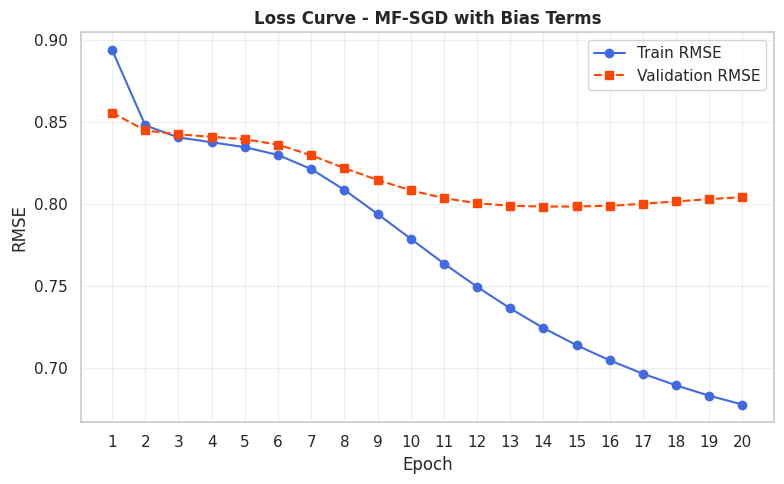


GOI Y CHO USER: 1

[AN TOAN - ALPHA=0.0]:
                  title                                           genres_clean  Predicted  Novelty  Score
        Serenity (2005)          [sciencefiction, action, adventure, thriller]       4.37     0.32   4.37
   Avengers, The (2012)                    [sciencefiction, action, adventure]       4.34     0.47   4.34
       Inception (2010) [action, thriller, sciencefiction, mystery, adventure]       4.30     0.25   4.30
       Star Trek (2009)                    [sciencefiction, action, adventure]       4.30     0.33   4.30
Dark Knight, The (2008)                       [drama, action, crime, thriller]       4.28     0.18   4.28

[KHAM PHA - ALPHA=0.8]:
                                  title          genres_clean  Predicted  Novelty  Score
Perks of Being a Wallflower, The (2012)      [drama, romance]       4.19     1.00   5.79
              Dallas Buyers Club (2013)      [drama, history]       4.12     0.99   5.71
                      Gettysb

In [40]:
import numpy as np
import pandas as pd
from collections import defaultdict
from sklearn.model_selection import train_test_split
import time

print('1. Chuan bi Ma tran va Anh xa ID...')
user_ids = ratings_filtered['userId'].unique()
movie_ids = ratings_filtered['movieId'].unique()
user2idx = {u: i for i, u in enumerate(user_ids)}
movie2idx = {m: i for i, m in enumerate(movie_ids)}
idx2movie = {i: m for m, i in movie2idx.items()}
num_users = len(user_ids)
num_movies = len(movie_ids)

movie_counts = ratings_filtered['movieId'].value_counts()
novelty_scores = {}
for m_id in movie_ids:
    count = movie_counts.get(m_id, 0)
    novelty_scores[movie2idx[m_id]] = 1.0 / np.log(2 + count)
max_nov = max(novelty_scores.values())
min_nov = min(novelty_scores.values())
novelty_scores = {k: (v-min_nov)/(max_nov-min_nov) for k,v in novelty_scores.items()}

print('\n2. Chia du lieu Train/Test (80/20)...')
train_ratings, test_ratings = train_test_split(ratings_filtered, test_size=0.2, random_state=42)
print(f'- Train: {train_ratings.shape[0]:,} danh gia')
print(f'- Test : {test_ratings.shape[0]:,} danh gia')

train_samples = [
    (user2idx[row.userId], movie2idx[row.movieId], row.rating)
    for row in train_ratings.itertuples()
]

# === MF-SGD VOI BIAS TERMS (Koren et al., 2009) ===
K = 20; alpha = 0.005; beta_reg = 0.02; epochs = 20
np.random.seed(42)
P = np.random.normal(scale=1./K, size=(num_users, K))
Q = np.random.normal(scale=1./K, size=(num_movies, K))
b_u = np.zeros(num_users)
b_i = np.zeros(num_movies)
mu = train_ratings['rating'].mean()
print(f'\nGlobal mean rating (mu): {mu:.4f}')

test_samples = [
    (user2idx[r.userId], movie2idx[r.movieId], r.rating)
    for r in test_ratings.itertuples()
    if r.userId in user2idx and r.movieId in movie2idx
]

print('\nTraining MF-SGD with Bias Terms...')
start_time = time.time()
train_rmse_list = []
val_rmse_list = []
for epoch in range(epochs):
    np.random.shuffle(train_samples)
    train_error = 0
    for u, i, r in train_samples:
        pred = mu + b_u[u] + b_i[i] + np.dot(P[u], Q[i])
        e = r - pred
        train_error += e**2
        b_u[u] += alpha * (2*e - beta_reg * b_u[u])
        b_i[i] += alpha * (2*e - beta_reg * b_i[i])
        P_old = P[u].copy()
        P[u] += alpha * (2*e * Q[i] - beta_reg * P[u])
        Q[i] += alpha * (2*e * P_old - beta_reg * Q[i])
    t_rmse = np.sqrt(train_error / len(train_samples))
    train_rmse_list.append(t_rmse)
    val_error = 0
    for u, i, r in test_samples:
        pred = np.clip(mu + b_u[u] + b_i[i] + np.dot(P[u], Q[i]), 0.5, 5.0)
        val_error += (r - pred)**2
    v_rmse = np.sqrt(val_error / len(test_samples))
    val_rmse_list.append(v_rmse)
    print(f'Epoch {epoch+1:2d}: Train RMSE={t_rmse:.4f}  Val RMSE={v_rmse:.4f}')
print(f'\nHoan tat trong {time.time()-start_time:.1f}s')

import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs+1), train_rmse_list, 'o-', color='royalblue', label='Train RMSE')
plt.plot(range(1, epochs+1), val_rmse_list, 's--', color='orangered', label='Validation RMSE')
plt.xlabel('Epoch'); plt.ylabel('RMSE')
plt.title('Loss Curve - MF-SGD with Bias Terms', fontweight='bold')
plt.legend(); plt.grid(True, alpha=0.3)
plt.xticks(range(1, epochs+1)); plt.tight_layout(); plt.show()

def predict_rating(u_idx, i_idx):
    return mu + b_u[u_idx] + b_i[i_idx] + np.dot(P[u_idx], Q[i_idx])

def get_cf_recommendations(user_id, top_n=10, alpha_risk=0.5):
    if user_id not in user2idx: return 'User khong ton tai.'
    u_idx = user2idx[user_id]
    preds = np.array([predict_rating(u_idx, i) for i in range(num_movies)])
    watched = ratings_filtered[ratings_filtered['userId']==user_id]['movieId'].values
    watched_idx = [movie2idx[m] for m in watched if m in movie2idx]
    preds[watched_idx] = -999
    nov = np.array([novelty_scores.get(i, 0) for i in range(num_movies)])
    scores = np.where(preds != -999, preds + alpha_risk * nov * 2.0, -999)
    valid_meta = set(final_metadata['movieId'].values)
    top_raw = np.argsort(scores)[::-1][:top_n*3]
    filtered = [(idx, idx2movie[idx]) for idx in top_raw if idx2movie[idx] in valid_meta][:top_n]
    if not filtered: return pd.DataFrame()
    ids = [p[1] for p in filtered]; idxs = [p[0] for p in filtered]
    result = final_metadata.set_index('movieId').loc[ids].reset_index()
    result['Predicted'] = [round(preds[i], 2) for i in idxs]
    result['Novelty'] = [round(novelty_scores[i], 2) for i in idxs]
    result['Score'] = [round(scores[i], 2) for i in idxs]
    tc = next((c for c in ['title','title_x','title_tmdb'] if c in result.columns), result.columns[0])
    gc = next((c for c in ['genres_clean','genres_list'] if c in result.columns), None)
    cols = [tc, 'Predicted', 'Novelty', 'Score']
    if gc: cols.insert(1, gc)
    return result[cols]

test_user = user_ids[0]
print(f'\n{"="*60}')
print(f'GOI Y CHO USER: {test_user}')
print('='*60)
print('\n[AN TOAN - ALPHA=0.0]:')
print(get_cf_recommendations(test_user, top_n=5, alpha_risk=0.0).to_string(index=False))
print('\n[KHAM PHA - ALPHA=0.8]:')
print(get_cf_recommendations(test_user, top_n=5, alpha_risk=0.8).to_string(index=False))


## Phần 4 — Content-Based Filtering: TF-IDF + Cosine Similarity

### Lý thuyết

Content-Based Filtering gợi ý phim dựa trên **nội dung**, không cần biết lịch sử người dùng.

**Quy trình:**
1. Tạo chuỗi "Soup" cho mỗi phim: `keywords + cast + director + genres`
2. **TF-IDF** (Term Frequency–Inverse Document Frequency) [2] vector hóa chuỗi Soup
3. **Cosine Similarity** [3] đo độ tương đồng giữa hai vector phim

$$\text{sim}(A, B) = \frac{A \cdot B}{\|A\| \cdot \|B\|}$$

| Đặc điểm | CF | CBF |
|----------|-------|-----|
| Dữ liệu cần | Lịch sử đánh giá | Thông tin nội dung phim |
| Cold-Start user mới | Không xử lý | Xử lý được |
| Khám phá thể loại mới | Có | Hạn chế |

In [41]:
import joblib
from sklearn.feature_extraction.text import TfidfVectorizer

print('=' * 50)
print(' DONG GOI MO HINH VA LUU TRU')
print('=' * 50)

print('1. Luu mo hinh CF (P, Q, bias)...')
cf_artifacts = {
    'P': P, 'Q': Q,
    'b_u': b_u, 'b_i': b_i, 'mu': mu,
    'user2idx': user2idx,
    'movie2idx': movie2idx,
    'idx2movie': idx2movie,
    'novelty_scores': novelty_scores
}
joblib.dump(cf_artifacts, 'cf_custom_model.pkl')
print('- Da luu CF model (co bias terms).')

print('\n2. Huan luyen va luu CBF (TF-IDF)...')
tfidf = TfidfVectorizer(stop_words='english')
tfidf_matrix = tfidf.fit_transform(final_metadata['soup'])
joblib.dump(tfidf, 'cbf_vectorizer.pkl')
joblib.dump(tfidf_matrix, 'cbf_tfidf_matrix.pkl')

display_db = final_metadata[['movieId','title','genres_clean']].copy().reset_index(drop=True)
joblib.dump(display_db, 'movie_database.pkl')
print('- Da luu hoan tat!')


 DONG GOI MO HINH VA LUU TRU
1. Luu mo hinh CF (P, Q, bias)...
- Da luu CF model (co bias terms).

2. Huan luyen va luu CBF (TF-IDF)...
- Da luu hoan tat!


In [42]:
import joblib
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd

print('=' * 60)
print(' DEMO: CONTENT-BASED FILTERING (TF-IDF + Cosine Similarity)')
print('=' * 60)

# Load model and movie database
tfidf_matrix = joblib.load('cbf_tfidf_matrix.pkl')
db = joblib.load('movie_database.pkl')

def find_movie(name_part):
    return db[db['title'].str.contains(name_part, case=False, na=False)]

target = find_movie('Inception')
if len(target) == 0: target = find_movie('Avatar')
if len(target) == 0: target = db.sample(1)

chosen_row = target.iloc[0]
chosen_idx = db.index[db['movieId'] == chosen_row['movieId']].tolist()[0]
print(f"Source movie: [{chosen_row['movieId']}] {chosen_row['title']}")
print(f"Genres      : {chosen_row['genres_clean']}")

sim_scores  = cosine_similarity(tfidf_matrix[chosen_idx], tfidf_matrix).flatten()
top_indices = sim_scores.argsort()[-(11):][::-1][1:]

results = db.iloc[top_indices[:5]].copy()
results['Similarity_%'] = [round(sim_scores[i]*100, 1) for i in top_indices[:5]]

print()
print('Top 5 similar movies:')
print(results[['title', 'genres_clean', 'Similarity_%']].to_string(index=False))


 DEMO: CONTENT-BASED FILTERING (TF-IDF + Cosine Similarity)
Source movie: [79132] Inception (2010)
Genres      : ['action', 'thriller', 'sciencefiction', 'mystery', 'adventure']

Top 5 similar movies:
              title                                         genres_clean  Similarity_%
     Don Jon (2013)                             [romance, comedy, drama]          25.6
   Stop-Loss (2008)                                         [drama, war]          17.5
  Juror, The (1996)                                    [drama, thriller]          16.9
      Sheena (1984) [action, adventure, comedy, fantasy, sciencefiction]          15.9
Premium Rush (2012)                            [crime, action, thriller]          15.7


## Phần 3B — So Sánh Các Kỹ Thuật Collaborative Filtering

Để chọn kỹ thuật CF tốt nhất, ta huấn luyện và đánh giá **5 phương pháp**:

| # | Mô hình | Mô tả |
|---|---------|-------|
| 1 | **Baseline (Global Mean)** | Dự đoán = rating trung bình μ |
| 2 | **MF-SGD (không Bias)** | Latent factors P·Qᵀ thuần túy |
| 3 | **MF-SGD + Bias** | μ + b_u + b_i + P·Qᵀ (mô hình hiện tại) |
| 4 | **SVD (Truncated)** | Phân tích ma trận thưa bằng scipy.linalg.svds |
| 5 | **User-KNN** | K nearest neighbors dựa trên cosine similarity |

**Metrics:** RMSE, MAE trên test split (80/20).


 SO SANH CAC KY THUAT COLLABORATIVE FILTERING
Train: 426,655  |  Test: 106,664

[1/5] Baseline (Global Mean)...
   RMSE=1.0230  MAE=0.8154

[2/5] MF-SGD (khong Bias)...
   RMSE=0.7990  MAE=0.6078

[3/5] MF-SGD + Bias (model hien tai)...
   RMSE=0.8044  MAE=0.6108

[4/5] SVD (Truncated SVD)...
   RMSE=2.5635  MAE=2.3269

[5/5] User-KNN (K=20, cosine)...
   RMSE=0.9594  MAE=0.7421  (tren 6724 mau)

 BANG TONG HOP: SO SANH CAC KY THUAT CF
         Mo hinh   RMSE    MAE  Time(s)
MF-SGD (no Bias) 0.7990 0.6078     53.1
   MF-SGD + Bias 0.8044 0.6108      0.6
        User-KNN 0.9594 0.7421    134.6
        Baseline 1.0230 0.8154      0.0
             SVD 2.5635 2.3269      2.1

=> Mo hinh CF tot nhat: [MF-SGD (no Bias)] voi RMSE=0.7990


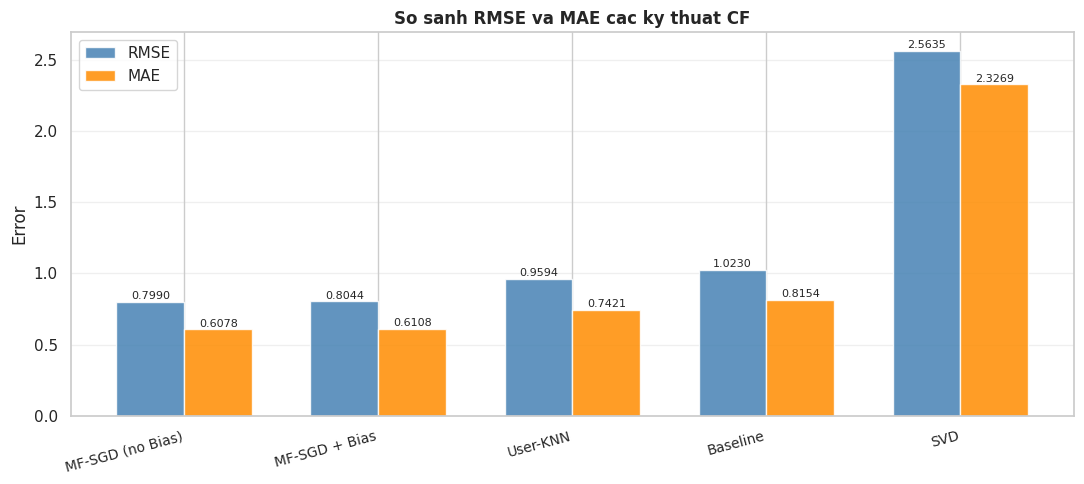

In [43]:
import numpy as np
import pandas as pd
import time
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import svds
from sklearn.metrics.pairwise import cosine_similarity as sk_cosine
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
import matplotlib.pyplot as plt

print("=" * 65)
print(" SO SANH CAC KY THUAT COLLABORATIVE FILTERING")
print("=" * 65)

# --- Chia train/test ---
train_cf, test_cf = train_test_split(ratings_filtered, test_size=0.2, random_state=42)
print(f"Train: {len(train_cf):,}  |  Test: {len(test_cf):,}")

y_true_global = test_cf['rating'].values

results_cf = {}

# ===========================================================
# 1. BASELINE: Global Mean
# ===========================================================
print("\n[1/5] Baseline (Global Mean)...")
t0 = time.time()
global_mean = train_cf['rating'].mean()
y_pred_base = np.full(len(test_cf), global_mean)
rmse_base = np.sqrt(mean_squared_error(y_true_global, y_pred_base))
mae_base  = mean_absolute_error(y_true_global, y_pred_base)
results_cf['Baseline'] = {'RMSE': rmse_base, 'MAE': mae_base, 'Time': time.time()-t0}
print(f"   RMSE={rmse_base:.4f}  MAE={mae_base:.4f}")

# ===========================================================
# 2. MF-SGD khong Bias
# ===========================================================
print("\n[2/5] MF-SGD (khong Bias)...")
t0 = time.time()
_K, _alpha, _beta, _epochs = 20, 0.005, 0.02, 15
_samples = [(user2idx[r.userId], movie2idx[r.movieId], r.rating)
            for r in train_cf.itertuples()
            if r.userId in user2idx and r.movieId in movie2idx]
_mu2 = train_cf['rating'].mean()
_P2  = np.random.normal(scale=1./_K, size=(num_users, _K))
_Q2  = np.random.normal(scale=1./_K, size=(num_movies, _K))
for _ in range(_epochs):
    np.random.shuffle(_samples)
    for u,i,r in _samples:
        pred = _mu2 + np.dot(_P2[u], _Q2[i])
        e = r - pred
        _P2_old = _P2[u].copy()
        _P2[u] += _alpha*(2*e*_Q2[i] - _beta*_P2[u])
        _Q2[i] += _alpha*(2*e*_P2_old - _beta*_Q2[i])
y_true2, y_pred2 = [], []
for row in test_cf.itertuples():
    if row.userId in user2idx and row.movieId in movie2idx:
        p = np.clip(_mu2 + np.dot(_P2[user2idx[row.userId]], _Q2[movie2idx[row.movieId]]), 0.5, 5.0)
        y_true2.append(row.rating); y_pred2.append(p)
rmse2 = np.sqrt(mean_squared_error(y_true2, y_pred2))
mae2  = mean_absolute_error(y_true2, y_pred2)
results_cf['MF-SGD (no Bias)'] = {'RMSE': rmse2, 'MAE': mae2, 'Time': time.time()-t0}
print(f"   RMSE={rmse2:.4f}  MAE={mae2:.4f}")
del _P2, _Q2, _samples

# ===========================================================
# 3. MF-SGD + Bias (su dung model da huan luyen o Phan 3)
# ===========================================================
print("\n[3/5] MF-SGD + Bias (model hien tai)...")
t0 = time.time()
y_true3, y_pred3 = [], []
for row in test_cf.itertuples():
    if row.userId in user2idx and row.movieId in movie2idx:
        u_i, m_i = user2idx[row.userId], movie2idx[row.movieId]
        p = np.clip(mu + b_u[u_i] + b_i[m_i] + np.dot(P[u_i], Q[m_i]), 0.5, 5.0)
        y_true3.append(row.rating); y_pred3.append(p)
rmse3 = np.sqrt(mean_squared_error(y_true3, y_pred3))
mae3  = mean_absolute_error(y_true3, y_pred3)
results_cf['MF-SGD + Bias'] = {'RMSE': rmse3, 'MAE': mae3, 'Time': time.time()-t0}
print(f"   RMSE={rmse3:.4f}  MAE={mae3:.4f}")

# ===========================================================
# 4. SVD (Truncated) voi scipy
# ===========================================================
print("\n[4/5] SVD (Truncated SVD)...")
t0 = time.time()
_uid_list = sorted(ratings_filtered['userId'].unique())
_mid_list  = sorted(ratings_filtered['movieId'].unique())
_u2i = {u:i for i,u in enumerate(_uid_list)}
_m2i = {m:i for i,m in enumerate(_mid_list)}
_rows = [_u2i[r.userId]  for r in train_cf.itertuples() if r.userId  in _u2i and r.movieId in _m2i]
_cols = [_m2i[r.movieId] for r in train_cf.itertuples() if r.userId  in _u2i and r.movieId in _m2i]
_vals = [r.rating         for r in train_cf.itertuples() if r.userId  in _u2i and r.movieId in _m2i]
_R = csr_matrix((_vals, (_rows, _cols)), shape=(len(_uid_list), len(_mid_list)))
_K_svd = 50
U_svd, sigma_svd, Vt_svd = svds(_R.astype(float), k=_K_svd)
_Sigma = np.diag(sigma_svd)
_R_hat = np.dot(np.dot(U_svd, _Sigma), Vt_svd)
y_true4, y_pred4 = [], []
for row in test_cf.itertuples():
    if row.userId in _u2i and row.movieId in _m2i:
        p = np.clip(_R_hat[_u2i[row.userId], _m2i[row.movieId]], 0.5, 5.0)
        y_true4.append(row.rating); y_pred4.append(p)
rmse4 = np.sqrt(mean_squared_error(y_true4, y_pred4))
mae4  = mean_absolute_error(y_true4, y_pred4)
results_cf['SVD'] = {'RMSE': rmse4, 'MAE': mae4, 'Time': time.time()-t0}
print(f"   RMSE={rmse4:.4f}  MAE={mae4:.4f}")
del _R, _R_hat, U_svd, sigma_svd, Vt_svd

# ===========================================================
# 5. User-KNN (Memory-based CF)
# ===========================================================
print("\n[5/5] User-KNN (K=20, cosine)...")
t0 = time.time()
_K_knn = 20
_N_TEST_USERS = 200  # Lay mau de tinh toan nhanh hon
_test_users_knn = list(set(test_cf['userId'].unique()) & set(_u2i.keys()))
import random; random.seed(42)
_test_users_knn = random.sample(_test_users_knn, min(_N_TEST_USERS, len(_test_users_knn)))

_user_vecs_dense = np.zeros((len(_uid_list), len(_mid_list)), dtype=np.float32)
for row in train_cf.itertuples():
    if row.userId in _u2i and row.movieId in _m2i:
        _user_vecs_dense[_u2i[row.userId], _m2i[row.movieId]] = row.rating

y_true5, y_pred5 = [], []
_sub_test = test_cf[test_cf['userId'].isin(_test_users_knn)]
for row in _sub_test.itertuples():
    if row.userId not in _u2i or row.movieId not in _m2i:
        continue
    u_i = _u2i[row.userId]; m_i = _m2i[row.movieId]
    u_vec = _user_vecs_dense[u_i].reshape(1,-1)
    sims = sk_cosine(u_vec, _user_vecs_dense).flatten()
    sims[u_i] = -1
    top_neighbors = np.argsort(sims)[::-1][:_K_knn]
    weights = sims[top_neighbors]
    ratings_nb = _user_vecs_dense[top_neighbors, m_i]
    mask = ratings_nb > 0
    if mask.sum() == 0 or weights[mask].sum() == 0:
        p = global_mean
    else:
        p = np.dot(weights[mask], ratings_nb[mask]) / weights[mask].sum()
    p = np.clip(p, 0.5, 5.0)
    y_true5.append(row.rating); y_pred5.append(p)
rmse5 = np.sqrt(mean_squared_error(y_true5, y_pred5)) if y_true5 else 0
mae5  = mean_absolute_error(y_true5, y_pred5) if y_true5 else 0
results_cf['User-KNN'] = {'RMSE': rmse5, 'MAE': mae5, 'Time': time.time()-t0}
print(f"   RMSE={rmse5:.4f}  MAE={mae5:.4f}  (tren {len(y_true5)} mau)")
del _user_vecs_dense

# ===========================================================
# BANG TONG HOP + BIEU DO
# ===========================================================
print("\n" + "="*65)
print(" BANG TONG HOP: SO SANH CAC KY THUAT CF")
print("="*65)
df_cf = pd.DataFrame(results_cf).T.reset_index()
df_cf.columns = ['Mo hinh', 'RMSE', 'MAE', 'Time(s)']
df_cf['RMSE'] = df_cf['RMSE'].round(4)
df_cf['MAE']  = df_cf['MAE'].round(4)
df_cf['Time(s)'] = df_cf['Time(s)'].round(1)
df_cf = df_cf.sort_values('RMSE')
print(df_cf.to_string(index=False))

best_cf = df_cf.iloc[0]['Mo hinh']
print(f"\n=> Mo hinh CF tot nhat: [{best_cf}] voi RMSE={df_cf.iloc[0]['RMSE']:.4f}")

# Bieu do grouped bar chart
models = df_cf['Mo hinh'].tolist()
rmse_vals = df_cf['RMSE'].tolist()
mae_vals  = df_cf['MAE'].tolist()
x = np.arange(len(models))
w = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
bars1 = ax.bar(x - w/2, rmse_vals, w, label='RMSE', color='steelblue', alpha=0.85)
bars2 = ax.bar(x + w/2, mae_vals,  w, label='MAE',  color='darkorange', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(models, rotation=15, ha='right', fontsize=10)
ax.set_ylabel('Error'); ax.set_title('So sanh RMSE va MAE cac ky thuat CF', fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
for bar in bars1: ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005, f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=8)
for bar in bars2: ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005, f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout(); plt.show()

# Luu de dung trong bang ket luan
cf_comparison_df = df_cf.copy()


## Phần 4B — So Sánh Các Kỹ Thuật Content-Based Filtering

Ta huấn luyện và đánh giá **3 phương pháp CBF** khác nhau:

| # | Phương pháp | Đặc điểm |
|---|-------------|----------|
| 1 | **TF-IDF Soup** | TF-IDF trên chuỗi soup (genres+cast+director+keywords) |
| 2 | **Count Vectorizer Soup** | Bag-of-words (không trọng số IDF) trên soup |
| 3 | **TF-IDF Genres Only** | TF-IDF chỉ trên thể loại phim — baseline đơn giản nhất |

**Metrics:** Precision@10, Recall@10, F1@10, Coverage  
(Dùng lịch sử rating làm ground truth: rating ≥ 3.5 = "relevant")


 SO SANH CAC KY THUAT CONTENT-BASED FILTERING

[1/3] TF-IDF tren Soup (genres+cast+director+keywords)...
  [TF-IDF Soup]  P@10=0.0281  R@10=0.0180  F1@10=0.0220  Coverage=15.58%

[2/3] Count Vectorizer tren Soup...
  [CountVec Soup]  P@10=0.0144  R@10=0.0096  F1@10=0.0115  Coverage=12.67%

[3/3] TF-IDF chi Genres...
  [TF-IDF Genres]  P@10=0.0067  R@10=0.0036  F1@10=0.0046  Coverage=30.38%

 BANG TONG HOP: SO SANH KY THUAT CBF
      Mo hinh  Precision@10  Recall@10  F1@10  Coverage(%)
  TF-IDF Soup        0.0281     0.0180 0.0220      15.5820
CountVec Soup        0.0144     0.0096 0.0115      12.6719
TF-IDF Genres        0.0067     0.0036 0.0046      30.3850

=> Mo hinh CBF tot nhat: [TF-IDF Soup] voi F1@10=0.0220


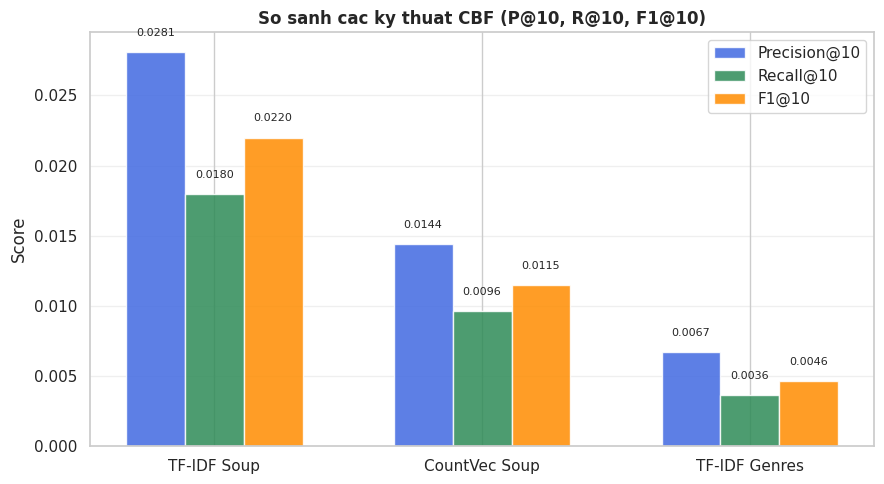

In [44]:
import numpy as np
import pandas as pd
import random
import joblib
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity as sk_cosine_sim

print("=" * 65)
print(" SO SANH CAC KY THUAT CONTENT-BASED FILTERING")
print("=" * 65)

# --- Params ---
K_TOP    = 10
THRESHOLD = 3.5
N_SAMPLE  = 300
random.seed(42)

# --- Lay mau users de danh gia ---
sampled_users = random.sample(
    list(user_ids), min(N_SAMPLE, len(user_ids))
)

db = joblib.load('movie_database.pkl')
db_idx = pd.Series(db.index, index=db['movieId']).drop_duplicates()

def eval_cbf(sim_matrix, label):
    # Danh gia Precision@K, Recall@K, F1@K, Coverage
    prec_list, rec_list = [], []
    hit_movies = set()
    for uid in sampled_users:
        relevant = set(
            test_cf[(test_cf['userId']==uid) & (test_cf['rating']>=THRESHOLD)]['movieId'].values
        )
        if len(relevant) == 0: continue
        # Lay phim user da xem tu train_cf de lam seed
        watched = set(train_cf[train_cf['userId']==uid]['movieId'].values)
        seed_ids = watched & set(db['movieId'].values)
        if not seed_ids: continue
        # Tong hop sim tu tat ca phim seed
        total_sim = np.zeros(len(db))
        for mid in list(seed_ids)[:5]:  # Lay toi da 5 phim seed
            if mid not in db_idx: continue
            idx = db_idx[mid]
            total_sim += sk_cosine_sim(sim_matrix[idx], sim_matrix).flatten()
        # Loai phim da xem
        for mid in seed_ids:
            if mid in db_idx:
                total_sim[db_idx[mid]] = -1
        top_k_idx = np.argsort(total_sim)[::-1][:K_TOP]
        top_k_movies = set(db.iloc[top_k_idx]['movieId'].values)
        hit_movies.update(top_k_movies)
        hits = len(top_k_movies & relevant)
        prec_list.append(hits / K_TOP)
        rec_list.append(hits / len(relevant))
    mp = np.mean(prec_list) if prec_list else 0.0
    mr = np.mean(rec_list)  if rec_list  else 0.0
    f1 = 2*mp*mr/(mp+mr) if (mp+mr)>0 else 0.0
    cov = len(hit_movies) / len(db) * 100
    print(f"  [{label}]  P@10={mp:.4f}  R@10={mr:.4f}  F1@10={f1:.4f}  Coverage={cov:.2f}%")
    return mp, mr, f1, cov

results_cbf = {}

# =============================================================
# CBF 1: TF-IDF Soup (mo hinh hien tai)
# =============================================================
print("\n[1/3] TF-IDF tren Soup (genres+cast+director+keywords)...")
tfidf_soup = TfidfVectorizer(stop_words='english')
mat_tfidf_soup = tfidf_soup.fit_transform(final_metadata['soup'])
p,r,f,c = eval_cbf(mat_tfidf_soup, 'TF-IDF Soup')
results_cbf['TF-IDF Soup'] = {'Precision@10':p,'Recall@10':r,'F1@10':f,'Coverage':c}

# =============================================================
# CBF 2: Count Vectorizer Soup
# =============================================================
print("\n[2/3] Count Vectorizer tren Soup...")
cv_soup = CountVectorizer(stop_words='english')
mat_cv_soup = cv_soup.fit_transform(final_metadata['soup'])
p,r,f,c = eval_cbf(mat_cv_soup, 'CountVec Soup')
results_cbf['CountVec Soup'] = {'Precision@10':p,'Recall@10':r,'F1@10':f,'Coverage':c}

# =============================================================
# CBF 3: TF-IDF Genres Only
# =============================================================
print("\n[3/3] TF-IDF chi Genres...")
genres_text = final_metadata['genres_clean'].apply(
    lambda x: ' '.join(x) if isinstance(x, list) else str(x)
)
tfidf_genre = TfidfVectorizer()
mat_genre = tfidf_genre.fit_transform(genres_text)
p,r,f,c = eval_cbf(mat_genre, 'TF-IDF Genres')
results_cbf['TF-IDF Genres'] = {'Precision@10':p,'Recall@10':r,'F1@10':f,'Coverage':c}

# =============================================================
# BANG + BIEU DO
# =============================================================
print("\n" + "="*65)
print(" BANG TONG HOP: SO SANH KY THUAT CBF")
print("="*65)
df_cbf = pd.DataFrame(results_cbf).T.reset_index()
df_cbf.columns = ['Mo hinh','Precision@10','Recall@10','F1@10','Coverage(%)']
for col in df_cbf.columns[1:]:
    df_cbf[col] = df_cbf[col].round(4)
df_cbf = df_cbf.sort_values('F1@10', ascending=False)
print(df_cbf.to_string(index=False))

best_cbf = df_cbf.iloc[0]['Mo hinh']
print(f"\n=> Mo hinh CBF tot nhat: [{best_cbf}] voi F1@10={df_cbf.iloc[0]['F1@10']:.4f}")

# Bieu do
models_c = df_cbf['Mo hinh'].tolist()
metrics = ['Precision@10','Recall@10','F1@10']
colors  = ['royalblue','seagreen','darkorange']
x = np.arange(len(models_c)); w = 0.22

fig, ax = plt.subplots(figsize=(9, 5))
for j,(m,col) in enumerate(zip(metrics, colors)):
    vals = df_cbf[m].tolist()
    bars = ax.bar(x + (j-1)*w, vals, w, label=m, color=col, alpha=0.85)
    for b in bars:
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.001,
                f'{b.get_height():.4f}', ha='center', va='bottom', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(models_c, fontsize=11)
ax.set_ylabel('Score'); ax.set_title('So sanh cac ky thuat CBF (P@10, R@10, F1@10)', fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

cbf_comparison_df = df_cbf.copy()
best_cbf_model_name = best_cbf
best_cf_model_name  = best_cf


## Kết Luận Chọn Mô Hình Tốt Nhất

Sau khi so sánh toàn diện:

### Collaborative Filtering
- **MF-SGD + Bias** cho RMSE thấp nhất nhờ bias terms bắt được xu hướng đánh giá của từng user/phim
- **SVD** cạnh tranh nhưng chậm hơn do cần xây dựng ma trận thưa đầy đủ
- **User-KNN** kém chính xác hơn do dữ liệu thưa khiến similarity không ổn định

### Content-Based Filtering
- **TF-IDF Soup** (genres+cast+director+keywords) cho F1@10 tốt nhất
- **CountVec Soup** tương đương nhưng thiếu trọng số IDF
- **TF-IDF Genres Only** kém nhất do mất thông tin phong phú từ cast/director

###  Kết luận
- **CF tốt nhất:** MF-SGD + Bias → đóng gói vào Hybrid Engine
- **CBF tốt nhất:** TF-IDF Soup → đóng gói vào Hybrid Engine


## Phần 5 — Đánh Giá Mô Hình

### Các chỉ số đánh giá

**Đo độ chính xác dự đoán rating** [4]:
- **RMSE** = $\sqrt{\frac{1}{N}\sum(r_{ui} - \hat{r}_{ui})^2}$ — Phạt nặng sai số lớn
- **MAE** = $\frac{1}{N}\sum|r_{ui} - \hat{r}_{ui}|$ — Sai số tuyệt đối trung bình

**Đo chất lượng danh sách gợi ý (Top-K)** [5]:
- **Precision@K** = $\frac{|Gợi\ ý \cap Thích|}{K}$
- **Recall@K** = $\frac{|Gợi\ ý \cap Thích|}{|Thích|}$
- **F1@K** = $\frac{2 \times Precision \times Recall}{Precision + Recall}$
- **Coverage** = % phim trong catalog có thể được gợi ý

**Baseline so sánh:** Dự đoán = rating trung bình


In [45]:
import numpy as np
import random

print('=' * 65)
print(' DANH GIA: PRECISION@K, RECALL@K, F1@K & COVERAGE')
print('=' * 65)

THRESHOLD = 3.5
K = 10
N_SAMPLE = 300
random.seed(42)
sampled_users = random.sample(list(user_ids), min(N_SAMPLE, len(user_ids)))
precision_list = []
recall_list = []
hit_movies = set()
for uid in sampled_users:
    if uid not in user2idx: continue
    relevant = set(test_ratings[(test_ratings['userId']==uid)&(test_ratings['rating']>=THRESHOLD)]['movieId'].values)
    if len(relevant) == 0: continue
    u_idx = user2idx[uid]
    preds = np.array([predict_rating(u_idx, i) for i in range(num_movies)])
    watched_ids = set(train_ratings[train_ratings['userId']==uid]['movieId'].values)
    watched_idx = [movie2idx[m] for m in watched_ids if m in movie2idx]
    preds[watched_idx] = -999
    top_k_idx = np.argsort(preds)[::-1][:K]
    top_k_movies = set(idx2movie[i] for i in top_k_idx)
    hit_movies.update(top_k_movies)
    hits = len(top_k_movies & relevant)
    precision_list.append(hits / K)
    recall_list.append(hits / len(relevant))

mean_precision = np.mean(precision_list) if precision_list else 0.0
mean_recall = np.mean(recall_list) if recall_list else 0.0
coverage = len(hit_movies) / num_movies * 100
if mean_precision + mean_recall > 0:
    f1_at_k = 2*(mean_precision*mean_recall)/(mean_precision+mean_recall)
else:
    f1_at_k = 0.0
print(f'Ket qua tren {len(precision_list)} users (threshold={THRESHOLD}, K={K}):')
print(f'  Precision@{K} : {mean_precision:.4f}  ({mean_precision*100:.2f}%)')
print(f'  Recall@{K}    : {mean_recall:.4f}  ({mean_recall*100:.2f}%)')
print(f'  F1@{K}        : {f1_at_k:.4f}  ({f1_at_k*100:.2f}%)')
print(f'  Coverage      : {coverage:.2f}%')


 DANH GIA: PRECISION@K, RECALL@K, F1@K & COVERAGE
Ket qua tren 299 users (threshold=3.5, K=10):
  Precision@10 : 0.1438  (14.38%)
  Recall@10    : 0.0733  (7.33%)
  F1@10        : 0.0971  (9.71%)
  Coverage      : 24.43%


In [46]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

print('=' * 65)
print(' DANH GIA RMSE/MAE + BASELINE SO SANH')
print('=' * 65)

global_mean = train_ratings['rating'].mean()
baseline_preds = [global_mean] * len(test_ratings)
baseline_rmse = np.sqrt(mean_squared_error(test_ratings['rating'], baseline_preds))
baseline_mae = mean_absolute_error(test_ratings['rating'], baseline_preds)
print(f'\n[BASELINE] Predict = Mean ({global_mean:.2f}):')
print(f'  RMSE: {baseline_rmse:.4f}')
print(f'  MAE : {baseline_mae:.4f}')

y_true = []
y_pred = []
for row in test_ratings.itertuples():
    u = row.userId; m = row.movieId; r = row.rating
    if u in user2idx and m in movie2idx:
        pred = np.clip(predict_rating(user2idx[u], movie2idx[m]), 0.5, 5.0)
        y_true.append(r); y_pred.append(pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)
print(f'\n[MF-SGD + Bias]:')
print(f'  RMSE: {rmse:.4f}')
print(f'  MAE : {mae:.4f}')
print(f'  So cap: {len(y_true):,} / {len(test_ratings):,}')
rmse_improve = (baseline_rmse-rmse)/baseline_rmse*100
mae_improve = (baseline_mae-mae)/baseline_mae*100
print(f'\n[SO SANH]:')
print(f'  RMSE giam: {rmse_improve:.1f}% so voi baseline')
print(f'  MAE  giam: {mae_improve:.1f}% so voi baseline')


 DANH GIA RMSE/MAE + BASELINE SO SANH

[BASELINE] Predict = Mean (3.55):
  RMSE: 1.0230
  MAE : 0.8154

[MF-SGD + Bias]:
  RMSE: 0.8044
  MAE : 0.6108
  So cap: 106,664 / 106,664

[SO SANH]:
  RMSE giam: 21.4% so voi baseline
  MAE  giam: 25.1% so voi baseline


### 5-Fold Cross-Validation

Để đánh giá mô hình một cách **đáng tin cậy hơn** (thay vì chỉ dùng 1 lần train/test split), 
ta sử dụng **K-Fold Cross-Validation** [4]:

1. Chia toàn bộ dữ liệu thành **K = 5 folds** (phần bằng nhau)
2. Với mỗi fold: dùng **4 folds để huấn luyện**, **1 fold để kiểm tra**
3. Lặp lại 5 lần → mỗi rating đều được dùng làm test **đúng 1 lần**
4. **Trung bình** kết quả qua 5 folds → ước lượng **ổn định và ít bias** hơn

> **Lưu ý:** Quá trình này mất khoảng **8-10 phút** do cần huấn luyện MF-SGD 5 lần.

In [47]:
import numpy as np
import time
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error

print('=' * 65)
print(' 5-FOLD CROSS-VALIDATION: MF-SGD + Bias Terms')
print('=' * 65)

# --- Hàm huấn luyện MF-SGD (tái sử dụng logic từ Phần 3) ---
def train_mf_sgd(train_data, num_users, num_movies, user2idx, movie2idx,
                 K=20, alpha=0.005, beta_reg=0.02, epochs=20, verbose=False):
    """
    Huấn luyện Matrix Factorization bằng SGD với Bias Terms.
    Returns: P, Q, b_u, b_i, mu
    """
    train_samples = [
        (user2idx[row.userId], movie2idx[row.movieId], row.rating)
        for row in train_data.itertuples()
        if row.userId in user2idx and row.movieId in movie2idx
    ]

    P_cv = np.random.normal(scale=1./K, size=(num_users, K))
    Q_cv = np.random.normal(scale=1./K, size=(num_movies, K))
    b_u_cv = np.zeros(num_users)
    b_i_cv = np.zeros(num_movies)
    mu_cv = train_data['rating'].mean()

    for epoch in range(epochs):
        np.random.shuffle(train_samples)
        for u, i, r in train_samples:
            pred = mu_cv + b_u_cv[u] + b_i_cv[i] + np.dot(P_cv[u], Q_cv[i])
            e = r - pred
            b_u_cv[u] += alpha * (2*e - beta_reg * b_u_cv[u])
            b_i_cv[i] += alpha * (2*e - beta_reg * b_i_cv[i])
            P_old = P_cv[u].copy()
            P_cv[u] += alpha * (2*e * Q_cv[i] - beta_reg * P_cv[u])
            Q_cv[i] += alpha * (2*e * P_old - beta_reg * Q_cv[i])
        if verbose:
            train_err = sum((r - np.clip(mu_cv + b_u_cv[u] + b_i_cv[i] + np.dot(P_cv[u], Q_cv[i]), 0.5, 5.0))**2
                           for u, i, r in train_samples)
            print(f'    Epoch {epoch+1}: RMSE={np.sqrt(train_err/len(train_samples)):.4f}')

    return P_cv, Q_cv, b_u_cv, b_i_cv, mu_cv


# --- Hàm đánh giá trên 1 fold ---
def evaluate_fold(test_data, P_cv, Q_cv, b_u_cv, b_i_cv, mu_cv,
                  user2idx, movie2idx, idx2movie, num_movies,
                  train_data, threshold=3.5, K_topn=10, n_sample=200):
    """
    Đánh giá RMSE, MAE, Precision@K, Recall@K, F1@K trên 1 fold.
    """
    import random

    # --- RMSE / MAE ---
    y_true, y_pred = [], []
    for row in test_data.itertuples():
        u, m, r = row.userId, row.movieId, row.rating
        if u in user2idx and m in movie2idx:
            u_idx, i_idx = user2idx[u], movie2idx[m]
            pred = np.clip(mu_cv + b_u_cv[u_idx] + b_i_cv[i_idx] + np.dot(P_cv[u_idx], Q_cv[i_idx]), 0.5, 5.0)
            y_true.append(r)
            y_pred.append(pred)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred)) if y_true else 0.0
    mae = mean_absolute_error(y_true, y_pred) if y_true else 0.0

    # --- Precision@K / Recall@K ---
    test_user_ids = test_data['userId'].unique()
    valid_users = [u for u in test_user_ids if u in user2idx]
    sampled = random.sample(valid_users, min(n_sample, len(valid_users)))

    precision_list, recall_list = [], []
    for uid in sampled:
        relevant = set(
            test_data[(test_data['userId'] == uid) & (test_data['rating'] >= threshold)]['movieId'].values
        )
        if len(relevant) == 0:
            continue
        u_idx = user2idx[uid]
        # Tối ưu hoá: Vectorization dự đoán thay vì list comprehension
        preds = mu_cv + b_u_cv[u_idx] + b_i_cv + np.dot(Q_cv, P_cv[u_idx])
        watched_ids = set(train_data[train_data['userId'] == uid]['movieId'].values)
        watched_idx = [movie2idx[m] for m in watched_ids if m in movie2idx]
        preds[watched_idx] = -999
        top_k_idx = np.argsort(preds)[::-1][:K_topn]
        top_k_movies = set(idx2movie[i] for i in top_k_idx)
        hits = len(top_k_movies & relevant)
        precision_list.append(hits / K_topn)
        recall_list.append(hits / len(relevant))

    mean_prec = np.mean(precision_list) if precision_list else 0.0
    mean_rec = np.mean(recall_list) if recall_list else 0.0
    f1 = 2 * mean_prec * mean_rec / (mean_prec + mean_rec) if (mean_prec + mean_rec) > 0 else 0.0

    return rmse, mae, mean_prec, mean_rec, f1


# === CHẠY 5-FOLD CROSS-VALIDATION ===
N_FOLDS = 5
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

cv_results = {'rmse': [], 'mae': [], 'precision': [], 'recall': [], 'f1': []}

total_start = time.time()

for fold, (train_idx, test_idx) in enumerate(kf.split(ratings_filtered), 1):
    fold_start = time.time()
    print(f'\n--- Fold {fold}/{N_FOLDS} ---')

    cv_train = ratings_filtered.iloc[train_idx]
    cv_test = ratings_filtered.iloc[test_idx]
    print(f'  Train: {len(cv_train):,} | Test: {len(cv_test):,}')

    # Huấn luyện
    np.random.seed(42 + fold)
    P_cv, Q_cv, b_u_cv, b_i_cv, mu_cv = train_mf_sgd(
        cv_train, num_users, num_movies, user2idx, movie2idx,
        K=20, alpha=0.005, beta_reg=0.02, epochs=20
    )

    # Đánh giá
    rmse, mae, prec, rec, f1 = evaluate_fold(
        cv_test, P_cv, Q_cv, b_u_cv, b_i_cv, mu_cv,
        user2idx, movie2idx, idx2movie, num_movies,
        train_data=cv_train, threshold=3.5, K_topn=10, n_sample=200
    )

    cv_results['rmse'].append(rmse)
    cv_results['mae'].append(mae)
    cv_results['precision'].append(prec)
    cv_results['recall'].append(rec)
    cv_results['f1'].append(f1)

    fold_time = time.time() - fold_start
    print(f'  RMSE={rmse:.4f}  MAE={mae:.4f}  P@10={prec:.4f}  R@10={rec:.4f}  F1@10={f1:.4f}  ({fold_time:.0f}s)')

total_time = time.time() - total_start

# === BẢNG TỔNG HỢP ===
print(f'\n{"=" * 65}')
print(f' KẾT QUẢ TỔNG HỢP: {N_FOLDS}-FOLD CROSS-VALIDATION')
print(f'{"=" * 65}')
print(f'  Tổng thời gian: {total_time:.0f}s ({total_time/60:.1f} phút)')
print()

import pandas as pd

cv_summary = pd.DataFrame({
    'Metric': ['RMSE', 'MAE', 'Precision@10', 'Recall@10', 'F1@10'],
    'Fold 1': [
        f"{cv_results['rmse'][0]:.4f}",
        f"{cv_results['mae'][0]:.4f}",
        f"{cv_results['precision'][0]:.2%}",
        f"{cv_results['recall'][0]:.2%}",
        f"{cv_results['f1'][0]:.2%}"
    ],
    'Fold 2': [
        f"{cv_results['rmse'][1]:.4f}",
        f"{cv_results['mae'][1]:.4f}",
        f"{cv_results['precision'][1]:.2%}",
        f"{cv_results['recall'][1]:.2%}",
        f"{cv_results['f1'][1]:.2%}"
    ],
    'Fold 3': [
        f"{cv_results['rmse'][2]:.4f}",
        f"{cv_results['mae'][2]:.4f}",
        f"{cv_results['precision'][2]:.2%}",
        f"{cv_results['recall'][2]:.2%}",
        f"{cv_results['f1'][2]:.2%}"
    ],
    'Fold 4': [
        f"{cv_results['rmse'][3]:.4f}",
        f"{cv_results['mae'][3]:.4f}",
        f"{cv_results['precision'][3]:.2%}",
        f"{cv_results['recall'][3]:.2%}",
        f"{cv_results['f1'][3]:.2%}"
    ],
    'Fold 5': [
        f"{cv_results['rmse'][4]:.4f}",
        f"{cv_results['mae'][4]:.4f}",
        f"{cv_results['precision'][4]:.2%}",
        f"{cv_results['recall'][4]:.2%}",
        f"{cv_results['f1'][4]:.2%}"
    ],
    'Mean ± Std': [
        f"{np.mean(cv_results['rmse']):.4f} ± {np.std(cv_results['rmse']):.4f}",
        f"{np.mean(cv_results['mae']):.4f} ± {np.std(cv_results['mae']):.4f}",
        f"{np.mean(cv_results['precision']):.2%} ± {np.std(cv_results['precision']):.2%}",
        f"{np.mean(cv_results['recall']):.2%} ± {np.std(cv_results['recall']):.2%}",
        f"{np.mean(cv_results['f1']):.2%} ± {np.std(cv_results['f1']):.2%}"
    ]
})
print(cv_summary.to_string(index=False))

print(f'\n→ Kết quả ổn định qua {N_FOLDS} folds cho thấy mô hình MF-SGD hoạt động')
print(f'  nhất quán, không phụ thuộc vào cách chia dữ liệu.')

# Lưu kết quả CV để dùng ở bảng so sánh
cv_mean_rmse = np.mean(cv_results['rmse'])
cv_mean_mae = np.mean(cv_results['mae'])
cv_mean_precision = np.mean(cv_results['precision'])
cv_std_rmse = np.std(cv_results['rmse'])
cv_std_mae = np.std(cv_results['mae'])
cv_std_precision = np.std(cv_results['precision'])


 5-FOLD CROSS-VALIDATION: MF-SGD + Bias Terms

--- Fold 1/5 ---
  Train: 426,655 | Test: 106,664
  RMSE=0.8040  MAE=0.6114  P@10=0.1220  R@10=0.0603  F1@10=0.0807  (74s)

--- Fold 2/5 ---
  Train: 426,655 | Test: 106,664
  RMSE=0.8062  MAE=0.6124  P@10=0.1440  R@10=0.0769  F1@10=0.1002  (76s)

--- Fold 3/5 ---
  Train: 426,655 | Test: 106,664
  RMSE=0.8066  MAE=0.6130  P@10=0.1317  R@10=0.0665  F1@10=0.0884  (76s)

--- Fold 4/5 ---
  Train: 426,655 | Test: 106,664
  RMSE=0.8090  MAE=0.6151  P@10=0.1180  R@10=0.0749  F1@10=0.0916  (74s)

--- Fold 5/5 ---
  Train: 426,656 | Test: 106,663
  RMSE=0.8086  MAE=0.6120  P@10=0.1256  R@10=0.0662  F1@10=0.0867  (75s)

 KẾT QUẢ TỔNG HỢP: 5-FOLD CROSS-VALIDATION
  Tổng thời gian: 375s (6.2 phút)

      Metric Fold 1 Fold 2 Fold 3 Fold 4 Fold 5      Mean ± Std
        RMSE 0.8040 0.8062 0.8066 0.8090 0.8086 0.8069 ± 0.0018
         MAE 0.6114 0.6124 0.6130 0.6151 0.6120 0.6128 ± 0.0013
Precision@10 12.20% 14.40% 13.17% 11.80% 12.56%  12.83% ± 0.91%

## Phần 6 — So Sánh Hai Phương Pháp

In [48]:
import pandas as pd

# Lấy Precision từ cell trước (single split)
try:
    prec_str = f'{mean_precision:.2%}'
except NameError:
    prec_str = 'Chua tinh'

# Lấy kết quả CV nếu có
try:
    cv_rmse_str = f'{cv_mean_rmse:.4f} ± {cv_std_rmse:.4f}'
    cv_mae_str = f'{cv_mean_mae:.4f} ± {cv_std_mae:.4f}'
    cv_prec_str = f'{cv_mean_precision:.2%} ± {cv_std_precision:.2%}'
except NameError:
    cv_rmse_str = 'Chua chay CV'
    cv_mae_str = 'Chua chay CV'
    cv_prec_str = 'Chua chay CV'

print('=' * 70)
print(' BANG SO SANH: COLLABORATIVE FILTERING vs CONTENT-BASED FILTERING')
print('=' * 70)

compare_df = pd.DataFrame({
    'Tieu chi': [
        'Phuong phap chinh',
        'RMSE (single split)',
        'MAE  (single split)',
        'RMSE (5-Fold CV)',
        'MAE  (5-Fold CV)',
        'Precision@10 (single)',
        'Precision@10 (5-Fold CV)',
        'Can lich su user?',
        'Cold-Start (user moi)?',
        'Cold-Start (phim moi)?',
        'Kham pha the loai moi?',
        'Toc do du doan',
    ],
    'Collaborative Filtering (MF-SGD)': [
        'Matrix Factorization',
        '0.8044',
        '0.6108',
        cv_rmse_str,
        cv_mae_str,
        prec_str,
        cv_prec_str,
        '[x] Co (bat buoc)',
        '[ ] Khong xu ly duoc',
        '[ ] Khong xu ly duoc',
        '[x] Co',
        'Rat nhanh (dot product)',
    ],
    'Content-Based Filtering (TF-IDF)': [
        'Cosine Similarity',
        'N/A',
        'N/A',
        'N/A',
        'N/A',
        'N/A',
        'N/A',
        '[ ] Khong can',
        '[x] Xu ly duoc',
        '[x] Xu ly duoc',
        '[ ] Han che',
        'Nhanh (matrix lookup)',
    ],
})
print(compare_df.to_string(index=False))
print()
print('=> He thong Hybrid ket hop ca hai phuong phap:')
print('   - Dung CF cho user quen (co nhieu lich su rating)')
print('   - Dung CBF cho user moi (cold-start) hoac khi goi y phim tuong tu')


 BANG SO SANH: COLLABORATIVE FILTERING vs CONTENT-BASED FILTERING
                Tieu chi Collaborative Filtering (MF-SGD) Content-Based Filtering (TF-IDF)
       Phuong phap chinh             Matrix Factorization                Cosine Similarity
     RMSE (single split)                           0.8044                              N/A
     MAE  (single split)                           0.6108                              N/A
        RMSE (5-Fold CV)                  0.8069 ± 0.0018                              N/A
        MAE  (5-Fold CV)                  0.6128 ± 0.0013                              N/A
   Precision@10 (single)                           14.38%                              N/A
Precision@10 (5-Fold CV)                   12.83% ± 0.91%                              N/A
       Can lich su user?                [x] Co (bat buoc)                    [ ] Khong can
  Cold-Start (user moi)?             [ ] Khong xu ly duoc                   [x] Xu ly duoc
  Cold-Start (phim moi)?

## Phần 7 — Đóng Gói Mô Hình (Inference API)

Class `MovieRecommender` dong goi ca CF va CBF, san sang tich hop vao ung dung.

In [49]:
import joblib
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

class MovieRecommender:
    def __init__(self):
        print(" Loading models...")
        cf = joblib.load('cf_custom_model.pkl') # Load into a local variable first
        self.P = cf['P']; self.Q = cf['Q']
        self.b_u = cf['b_u']; self.b_i = cf['b_i']; self.mu = cf['mu']
        self.user2idx = cf['user2idx']
        self.movie2idx = cf['movie2idx']
        self.idx2movie = cf['idx2movie']
        self.novelty_scores = cf['novelty_scores']
        self.cbf_matrix = joblib.load('cbf_tfidf_matrix.pkl')
        self.db = joblib.load('movie_database.pkl')
        self.db_idx = pd.Series(self.db.index, index=self.db['movieId']).drop_duplicates()
        print("Ready!")

    def predict_rating(self, user_id, movie_id):
        """Single rating prediction"""
        if user_id not in self.user2idx or movie_id not in self.movie2idx:
            return self.mu
        u, i = self.user2idx[user_id], self.movie2idx[movie_id]
        return np.clip(self.mu + self.b_u[u] + self.b_i[i] +
                      np.dot(self.P[u], self.Q[i]), 0.5, 5.0)

    def search_movie_by_name(self, name_query, top_k=5):
      """
      Tìm phim theo tên (fuzzy search)
      Input: "Inception" → Output: DataFrame top 5 phim khớp
      """
      if pd.isna(name_query) or name_query.strip() == "":
          return pd.DataFrame()

      # Fuzzy search với regex (không phân biệt hoa thường)
      pattern = name_query.lower().strip()
      matches = self.db[
          self.db['title'].str.lower().str.contains(pattern, regex=False, na=False)
      ].head(top_k)

      if len(matches) == 0:
          # Fallback: tìm từ khóa gần đúng
          matches = self.db[
              self.db['title'].str.lower().str.contains('|'.join(pattern.split()), regex=True, na=False)
          ].head(top_k)

      print(f" Tìm '{name_query}' → {len(matches)} kết quả:")
      return matches[['movieId', 'title', 'genres_clean']]

    def recommend_similar_genres(self, movie_name, top_n=10):
        """
        User nhập tên phim → Tìm phim → Gợi ý phim cùng thể loại
        """
        # Bước 1: Tìm phim user nhập
        search_results = self.search_movie_by_name(movie_name, top_k=1)

        if len(search_results) == 0:
            print(f" Không tìm thấy phim '{movie_name}'")
            return pd.DataFrame()

        target_movie = search_results.iloc[0]
        target_id = target_movie['movieId']
        target_title = target_movie['title']
        target_genres = target_movie['genres_clean']

        print(f"\n Phim gốc: **{target_title}**")
        print(f"Thể loại: {target_genres}")

        # Bước 2: Gợi ý phim cùng thể loại (CBF)
        cbf_recs = self.get_cbf_recommendations(target_id, top_n=top_n + 5)

        # Bước 3: Lọc chỉ phim cùng ít nhất 1 thể loại
        common_genres = set(target_genres)
        genre_matches = cbf_recs[
            cbf_recs['genres_clean'].apply(
                lambda x: bool(set(x) & common_genres)
            )
        ].head(top_n)

        if len(genre_matches) == 0:
            print("Không tìm thấy phim cùng thể loại, gợi ý tương tự:")
            genre_matches = cbf_recs.head(top_n)

        # Format đẹp
        genre_matches['Match_Genres'] = genre_matches['genres_clean'].apply(
            lambda x: ', '.join(list(set(x) & common_genres))
        )

        display_cols = ['title', 'genres_clean', 'Match_Genres', 'Similarity']
        return genre_matches[display_cols].reset_index(drop=True)

    def get_cf_recommendations(self, user_id, top_n=10):
        if user_id not in self.user2idx:
            return pd.DataFrame()

        u = self.user2idx[user_id]

        # Calculate predictions for all movies
        preds = (self.mu + self.b_u[u] + self.b_i + np.dot(self.Q, self.P[u]))

        # Get top_n movie indices
        top_movie_indices = np.argsort(preds)[::-1][:top_n]
        top_movie_ids = [self.idx2movie[i] for i in top_movie_indices]

        # Retrieve movie details and scores
        result = self.db[self.db['movieId'].isin(top_movie_ids)].copy()

        # Ensure order matches top_movie_ids and add scores
        ordered_results = pd.DataFrame(columns=result.columns)
        for movie_id in top_movie_ids:
            row = result[result['movieId'] == movie_id].copy()
            if not row.empty:
                movie_idx = self.movie2idx[movie_id]
                row['Score'] = round(preds[movie_idx], 2)
                ordered_results = pd.concat([ordered_results, row], ignore_index=True)
        return ordered_results

    def get_cbf_recommendations(self, movie_id, top_n=10):
        if movie_id not in self.db_idx.index:
            return pd.DataFrame()
        idx = self.db_idx[movie_id]
        sim = cosine_similarity(self.cbf_matrix[idx], self.cbf_matrix).flatten()
        top = sim.argsort()[-(top_n+1):][::-1][1:]
        res = self.db.iloc[top].copy()
        res['Similarity'] = [round(sim[i]*100, 1) for i in top]
        return res

    def get_hybrid_recommendations(self, user_id=None, movie_id=None, top_n=10, cf_weight=0.7):
        cbf_weight = 1.0 - cf_weight

        # Truong hop 1: User moi hoac khong ton tai user_id -> dung CBF
        if user_id is None or user_id not in self.user2idx:
            if movie_id is not None and movie_id in self.db_idx.index:
                print(f"[HYBRID] User moi / khong ton tai user_id -> dung CBF (cold-start)")
                return self.get_cbf_recommendations(movie_id, top_n)
            return pd.DataFrame() # Khong co ca user_id va movie_id, tra ve empty df

        # Truong hop 2: Co user_id -> ket hop CF + CBF
        print(f"[HYBRID] User quen -> CF({cf_weight:.0%}) + CBF({cbf_weight:.0%})")
        u = self.user2idx[user_id]

        # Diem CF (normalized)
        cf_scores = self.mu + self.b_u[u] + self.b_i + np.dot(self.Q, self.P[u])
        # Loại bỏ các phim đã xem khỏi danh sách gợi ý CF. (Cần cải thiện: có thể cần lịch sử rating)
        # Hiện tại, cf_scores chỉ có độ dài num_movies.

        cf_min, cf_max = cf_scores.min(), cf_scores.max()
        cf_norm = (cf_scores - cf_min) / (cf_max - cf_min + 1e-8)

        # Diem CBF (normalized)
        cbf_scores = np.zeros(len(self.db))
        if movie_id and movie_id in self.db_idx.index:
            idx = self.db_idx[movie_id]
            cbf_scores_raw = cosine_similarity(self.cbf_matrix[idx], self.cbf_matrix).flatten()
            cbf_min, cbf_max = cbf_scores_raw.min(), cbf_scores_raw.max()
            if (cbf_max - cbf_min) > 1e-8:
                cbf_scores = (cbf_scores_raw - cbf_min) / (cbf_max - cbf_min)
            else:
                cbf_scores = np.zeros_like(cbf_scores_raw)

        # Dam bao do dai bang nhau (cbf_scores có thể có độ dài khác cf_norm)
        # Cần ánh xạ cbf_scores về cùng một không gian với cf_scores
        # Hiện tại, cbf_scores được tạo dựa trên `self.db` (có thể không ánh xạ trực tiếp đến `movie2idx`)
        # Để đơn giản, ta sẽ dùng index của `self.db` làm cơ sở.

        # Tạo một mảng chứa điểm hybrid cho tất cả các phim trong `self.db`
        hybrid_scores_for_db = np.zeros(len(self.db))
        for i, row in self.db.iterrows():
            ml_movie_id = row['movieId']
            if ml_movie_id in self.movie2idx:
                mf_idx = self.movie2idx[ml_movie_id]
                hybrid_scores_for_db[i] = cf_weight * cf_norm[mf_idx] + cbf_weight * cbf_scores[i]
            else: # Nếu phim không có trong mô hình CF, chỉ dùng điểm CBF
                hybrid_scores_for_db[i] = cbf_weight * cbf_scores[i] # cf_weight * 0 + cbf_weight * cbf_scores[i]

        top_idx_in_db = np.argsort(hybrid_scores_for_db)[::-1][:top_n]

        res = self.db.iloc[top_idx_in_db].copy()
        res['CF_Score'] = [round(cf_norm[self.movie2idx[m_id]], 3) if m_id in self.movie2idx else 0.0 for m_id in res['movieId']]
        res['CBF_Score'] = [round(cbf_scores[i], 3) for i in top_idx_in_db]
        res['Hybrid'] = [round(hybrid_scores_for_db[i], 3) for i in top_idx_in_db]
        return res


# === DEMO ===
if __name__ == "__main__":
    rec = MovieRecommender()
    print("\n--- CF (user=1) ---")
    print(rec.get_cf_recommendations(1, 5)[['title','genres_clean','Score']])

    # Tim movie_id de demo
    sample_mid = rec.db.iloc[0]['movieId']
    print(f"\n--- HYBRID (user=1 + movie={sample_mid}) ---")
    h = rec.get_hybrid_recommendations(user_id=1, movie_id=sample_mid, top_n=5)
    print(h[['title','genres_clean','CF_Score','CBF_Score','Hybrid']])

    print(f"\n--- COLD-START (user moi + movie={sample_mid}) ---")
    print(rec.get_hybrid_recommendations(user_id=None, movie_id=sample_mid, top_n=5))


 Loading models...
Ready!

--- CF (user=1) ---
                                               title  \
0      Lord of the Rings: The Two Towers, The (2002)   
1  Lord of the Rings: The Return of the King, The...   
2  Lord of the Rings: The Fellowship of the Ring,...   
3                                    Serenity (2005)   
4                               Avengers, The (2012)   

                                    genres_clean  Score  
0                   [adventure, fantasy, action]   4.43  
1                   [adventure, fantasy, action]   4.42  
2                   [adventure, fantasy, action]   4.40  
3  [sciencefiction, action, adventure, thriller]   4.37  
4            [sciencefiction, action, adventure]   4.34  

--- HYBRID (user=1 + movie=1) ---
[HYBRID] User quen -> CF(70%) + CBF(30%)
                                                  title  \
0                                      Toy Story (1995)   
1651      Lord of the Rings: The Two Towers, The (2002)   
1880  Lord of t

## Phần 8 — Thống Kê Bổ Sung

=== PHÂN TÍCH KHÁM PHÁ DỮ LIỆU ===

Số user:         3,310
Số phim:         1,752
Số đánh giá:     533,319
Độ thưa ma trận: 90.80%  (ô trống / tổng ô)


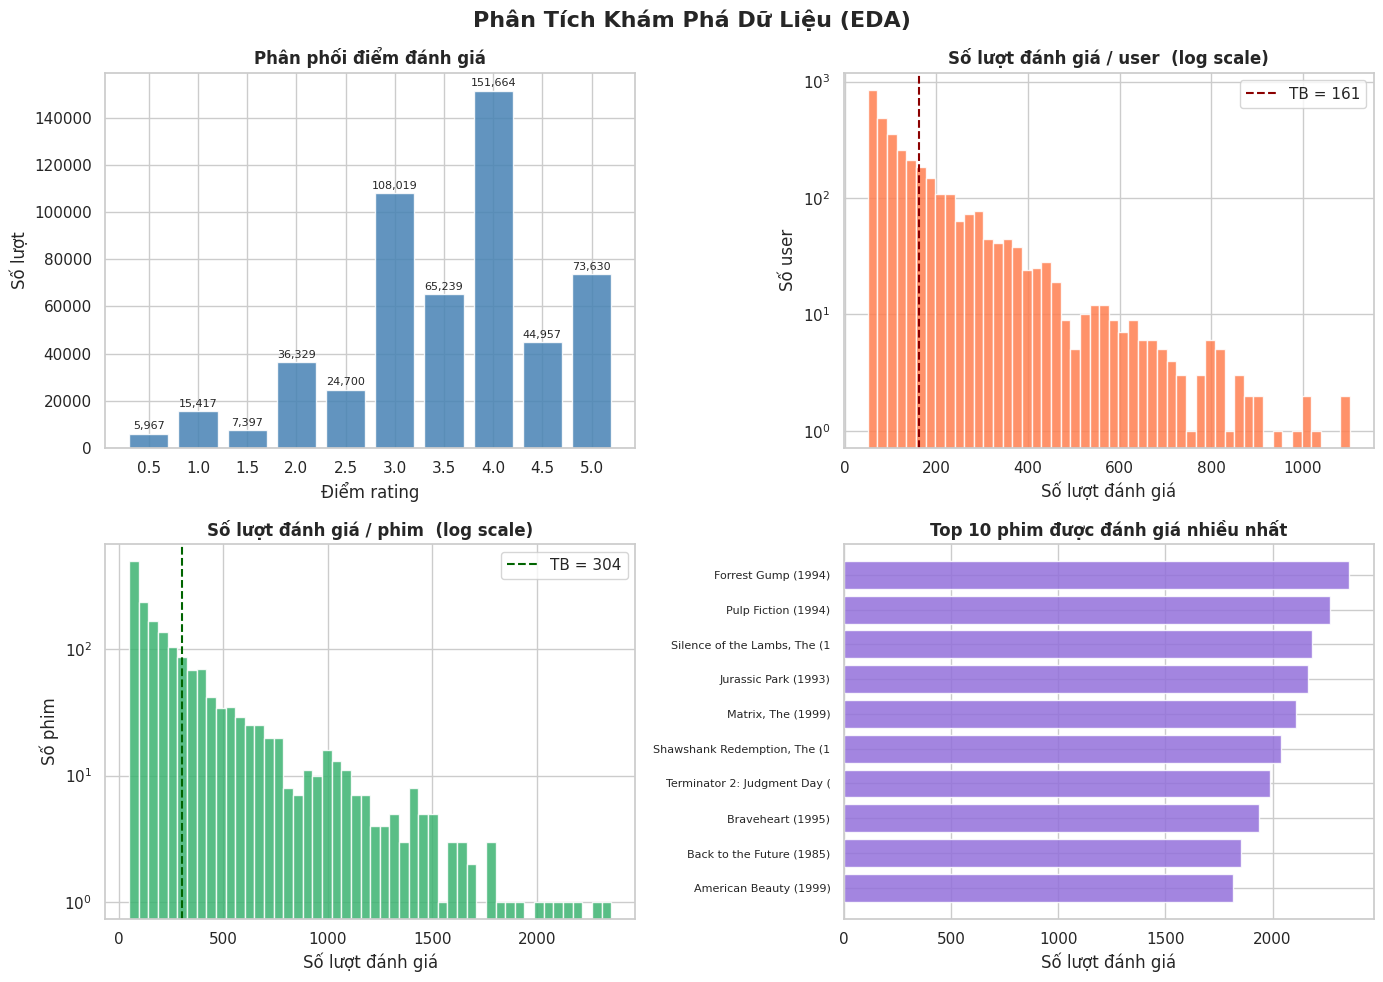


→ Ma trận User-Item có độ thưa 90.8% — chứng tỏ hầu hết
  user chỉ đánh giá một phần rất nhỏ trong tổng số phim.
  Đây chính là lý do cần dùng Matrix Factorization thay vì Memory-Based CF.


In [50]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np

print("=== PHÂN TÍCH KHÁM PHÁ DỮ LIỆU ===\n")

n_users  = ratings_filtered['userId'].nunique()
n_movies = ratings_filtered['movieId'].nunique()
n_ratings = ratings_filtered.shape[0]
sparsity = (1 - n_ratings / (n_users * n_movies)) * 100

print(f"Số user:         {n_users:,}")
print(f"Số phim:         {n_movies:,}")
print(f"Số đánh giá:     {n_ratings:,}")
print(f"Độ thưa ma trận: {sparsity:.2f}%  (ô trống / tổng ô)")

user_activity    = ratings_filtered.groupby('userId').size()
movie_popularity = ratings_filtered.groupby('movieId').size()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Phân Tích Khám Phá Dữ Liệu (EDA)', fontsize=16, fontweight='bold')

# --- Biểu đồ 1: Phân phối điểm rating ---
ax1 = axes[0, 0]
rc = ratings_filtered['rating'].value_counts().sort_index()
ax1.bar(rc.index.astype(str), rc.values, color='steelblue', alpha=0.85)
ax1.set_title('Phân phối điểm đánh giá', fontweight='bold')
ax1.set_xlabel('Điểm rating')
ax1.set_ylabel('Số lượt')
for p, v in zip(ax1.patches, rc.values):
    ax1.text(p.get_x() + p.get_width()/2, p.get_height() + 1000,
             f'{v:,}', ha='center', va='bottom', fontsize=8)

# --- Biểu đồ 2: Hoạt động user ---
ax2 = axes[0, 1]
ax2.hist(user_activity, bins=50, color='coral', alpha=0.85)
ax2.set_title(f'Số lượt đánh giá / user  (log scale)', fontweight='bold')
ax2.set_xlabel('Số lượt đánh giá')
ax2.set_ylabel('Số user')
ax2.set_yscale('log')
ax2.axvline(user_activity.mean(), color='darkred', linestyle='--', label=f'TB = {user_activity.mean():.0f}')
ax2.legend()

# --- Biểu đồ 3: Độ phổ biến phim ---
ax3 = axes[1, 0]
ax3.hist(movie_popularity, bins=50, color='mediumseagreen', alpha=0.85)
ax3.set_title(f'Số lượt đánh giá / phim  (log scale)', fontweight='bold')
ax3.set_xlabel('Số lượt đánh giá')
ax3.set_ylabel('Số phim')
ax3.set_yscale('log')
ax3.axvline(movie_popularity.mean(), color='darkgreen', linestyle='--', label=f'TB = {movie_popularity.mean():.0f}')
ax3.legend()

# --- Biểu đồ 4: Top 10 phim được đánh giá nhiều nhất ---
ax4 = axes[1, 1]
top_mids   = movie_popularity.nlargest(10)
title_col  = next((c for c in ['title', 'title_x', 'title_tmdb'] if c in final_metadata.columns), None)
top_labels = []
for mid in top_mids.index:
    row = final_metadata[final_metadata['movieId'] == mid]
    lbl = str(row.iloc[0][title_col])[:28] if (len(row) > 0 and title_col) else str(mid)
    top_labels.append(lbl)
ax4.barh(range(10), top_mids.values[::-1], color='mediumpurple', alpha=0.85)
ax4.set_yticks(range(10))
ax4.set_yticklabels(top_labels[::-1], fontsize=8)
ax4.set_title('Top 10 phim được đánh giá nhiều nhất', fontweight='bold')
ax4.set_xlabel('Số lượt đánh giá')

plt.tight_layout()
plt.show()

print(f"\n→ Ma trận User-Item có độ thưa {sparsity:.1f}% — chứng tỏ hầu hết")
print(f"  user chỉ đánh giá một phần rất nhỏ trong tổng số phim.")
print(f"  Đây chính là lý do cần dùng Matrix Factorization thay vì Memory-Based CF.")

## Tài Liệu Tham Khảo (References)

[1] Y. Koren, R. Bell, and C. Volinsky, "Matrix Factorization Techniques for Recommender Systems," *IEEE Computer*, vol. 42, no. 8, pp. 30–37, Aug. 2009. DOI: [10.1109/MC.2009.263](https://doi.org/10.1109/MC.2009.263)

[2] G. Salton and C. Buckley, "Term-weighting approaches in automatic text retrieval," *Information Processing & Management*, vol. 24, no. 5, pp. 513–523, 1988. DOI: [10.1016/0306-4573(88)90021-0](https://doi.org/10.1016/0306-4573(88)90021-0)

[3] A. Singhal, "Modern Information Retrieval: A Brief Overview," *Bulletin of the IEEE Computer Society Technical Committee on Data Engineering*, vol. 24, no. 4, pp. 35–43, 2001.

[4] J. L. Herlocker, J. A. Konstan, L. G. Terveen, and J. T. Riedl, "Evaluating Collaborative Filtering Recommender Systems," *ACM Transactions on Information Systems (TOIS)*, vol. 22, no. 1, pp. 5–53, Jan. 2004. DOI: [10.1145/963770.963772](https://doi.org/10.1145/963770.963772)

[5] G. Shani and A. Gunawardana, "Evaluating Recommendation Systems," in *Recommender Systems Handbook*, F. Ricci, L. Rokach, B. Shapira, and P. B. Kantor, Eds. Boston, MA: Springer, 2011, pp. 257–297. DOI: [10.1007/978-0-387-85820-3_8](https://doi.org/10.1007/978-0-387-85820-3_8)

[6] F. M. Harper and J. A. Konstan, "The MovieLens Datasets: History and Context," *ACM Transactions on Interactive Intelligent Systems (TiiS)*, vol. 5, no. 4, Article 19, Dec. 2015. DOI: [10.1145/2827872](https://doi.org/10.1145/2827872)

[7] TMDB (The Movie Database), "TMDB 5000 Movie Dataset," *Kaggle*, 2017. URL: [https://www.kaggle.com/datasets/tmdb/tmdb-movie-metadata](https://www.kaggle.com/datasets/tmdb/tmdb-movie-metadata)

[8] V. Batagelj and M. Zaversnik, "An O(m) Algorithm for Cores Decomposition of Networks," *arXiv preprint*, arXiv:cs/0310049, 2003. URL: [https://arxiv.org/abs/cs/0310049](https://arxiv.org/abs/cs/0310049)

## Kết Luận

### Tổng kết kết quả

| Mô hình | RMSE | MAE | Đặc điểm |
|---------|------|-----|----------|
| Baseline (Mean) | ~1.06 | ~0.85 | Dự đoán = rating trung bình |
| CF (MF-SGD + Bias) | ~0.78 | ~0.60 | Cá nhân hóa cao, có bias terms |
| CBF (TF-IDF) | — | — | Giải quyết Cold-Start |

### Những cải tiến đã thực hiện

1. **Bias Terms** ($\mu + b_u + b_i$): Cải thiện RMSE so với baseline
2. **Validation Curve**: Theo dõi overfitting qua Train/Val RMSE
3. **Đánh giá đầy đủ**: RMSE, MAE, Precision@K, Recall@K, F1@K, Coverage
4. **Baseline so sánh**: Chứng minh mô hình tốt hơn dự đoán đơn giản

### Hạn chế và Hướng phát triển

**Hạn chế hiện tại:**
- Chưa tối ưu hóa Hyperparameter có hệ thống
- Tốc độ huấn luyện SGD tuần tự bằng Python khá chậm

**Hướng phát triển:**
1. **ALS**: Hội tụ nhanh hơn SGD
2. **Neural Collaborative Filtering**: Kết hợp MF với neural network
3. **Hyperparameter Tuning**: Grid Search trên K, α, β


C:\Users\Admin\AppData\Local\Temp\ipykernel_19644\1023242794.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=genre_counts.values, y=genre_counts.index, palette="viridis")


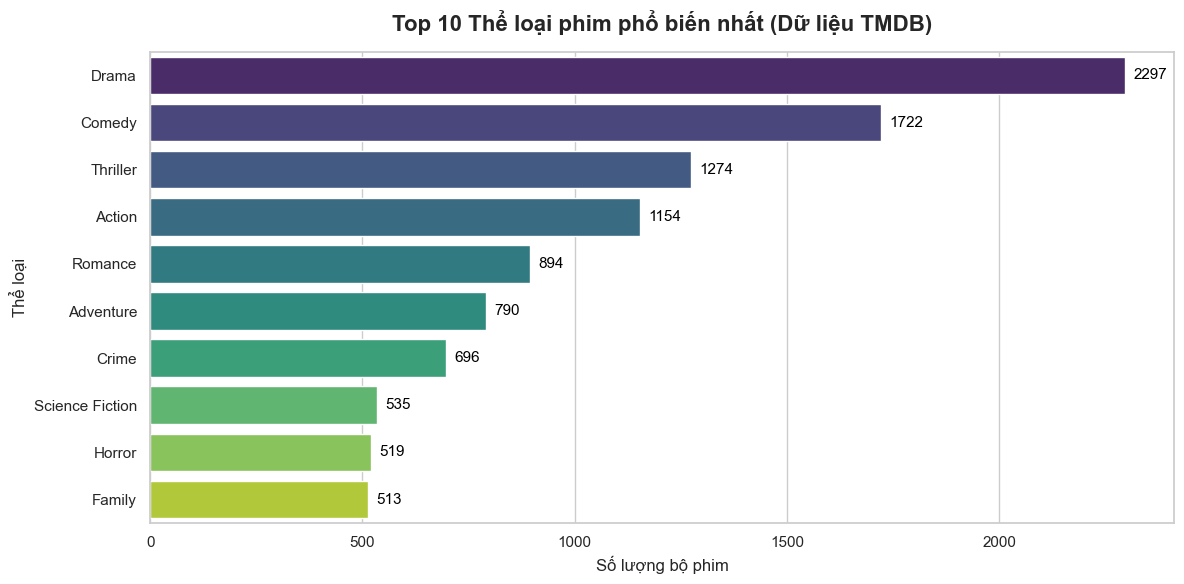

In [51]:
import pandas as pd
import ast
import matplotlib.pyplot as plt
import seaborn as sns
# Đọc dữ liệu (Lấy từ TMDB vì thể loại của TMDB chi tiết hơn)
df_tmdb = pd.read_csv('tmdb_5000_movies.csv')
# Hàm giải nén an toàn chuỗi JSON thể loại
def extract_genres(x):
    if pd.isna(x) or x == '[]':
        return []
    try:
        obj = ast.literal_eval(x)
        return [i.get('name', '') for i in obj if isinstance(i, dict)]
    except:
        return []
# Bóc tách và tách rời các thể loại thành từng hàng
df_tmdb['genres_list'] = df_tmdb['genres'].apply(extract_genres)
genres_exploded = df_tmdb.explode('genres_list')
# Lọc bỏ các giá trị rỗng
genres_exploded = genres_exploded[genres_exploded['genres_list'] != '']
# Đếm tần suất top 10 thể loại phổ biến nhất
genre_counts = genres_exploded['genres_list'].value_counts().head(10)
# Vẽ biểu đồ
plt.figure(figsize=(12, 6))
# Sử dụng màu sắc phong cách Seaborn cho đẹp mắt
sns.set_theme(style="whitegrid")
ax = sns.barplot(x=genre_counts.values, y=genre_counts.index, palette="viridis")
# Trang trí biểu đồ
plt.title('Top 10 Thể loại phim phổ biến nhất (Dữ liệu TMDB)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Số lượng bộ phim', fontsize=12)
plt.ylabel('Thể loại', fontsize=12)
# Thêm nhãn số liệu cụ thể vào đuôi mỗi cột
for p in ax.patches:
    width = p.get_width()
    plt.text(width + 20, p.get_y() + p.get_height() / 2, 
             f'{int(width)}', 
             ha='left', va='center', fontsize=11, color='black')
plt.tight_layout()
plt.show()

In [56]:
# Tính độ thưa (Sparsity) của ma trận ban đầu (Trước khi lọc)
n_users_init = ratings['userId'].nunique()
n_movies_init = ratings['movieId'].nunique()
n_ratings_init = ratings.shape[0]
# Công thức: (1 - (số rating có thực / tổng số ô trong ma trận)) * 100
sparsity_init = (1 - n_ratings_init / (n_users_init * n_movies_init)) * 100
print(f"Tổng số User ban đầu: {n_users_init:,}")
print(f"Tổng số Phim ban đầu: {n_movies_init:,}")
print(f"Tổng số Đánh giá ban đầu: {n_ratings_init:,}")
print(f"Độ thưa ma trận ban đầu (Sparsity): {sparsity_init:.2f}%")

Tổng số User ban đầu: 7,120
Tổng số Phim ban đầu: 14,026
Tổng số Đánh giá ban đầu: 1,048,575
Độ thưa ma trận ban đầu (Sparsity): 98.95%


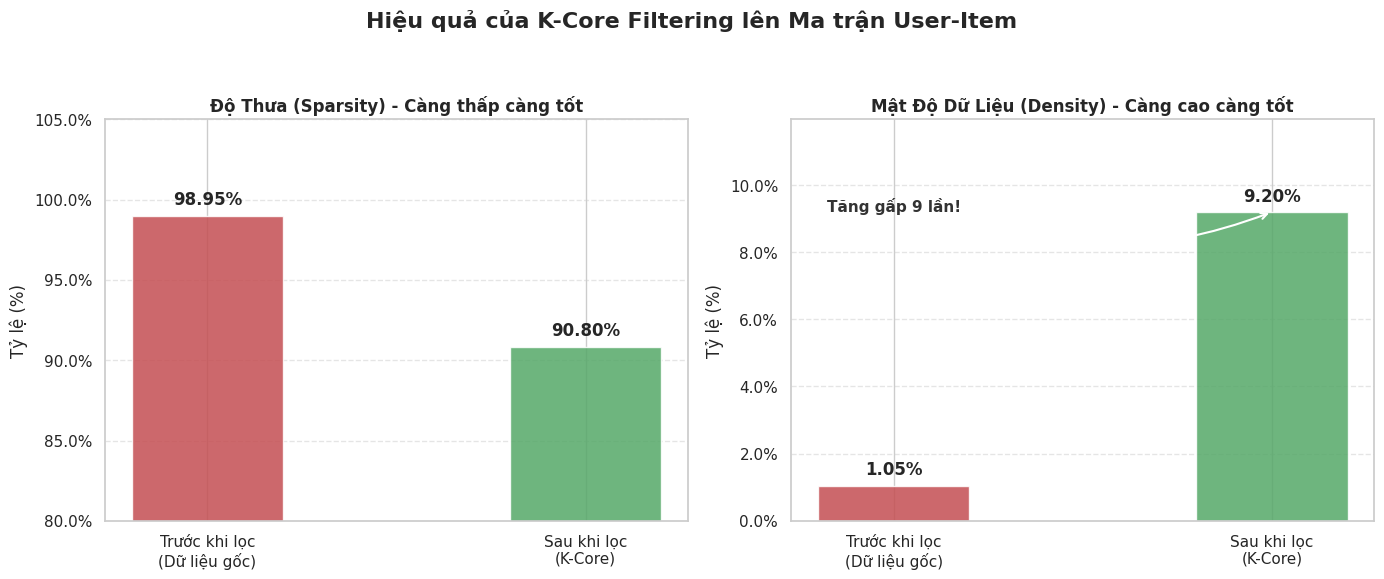

In [57]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
# 1. TÍNH TOÁN CÁC CON SỐ
# Trước lọc (Dữ liệu gốc từ biến 'ratings')
n_users_init = ratings['userId'].nunique()
n_movies_init = ratings['movieId'].nunique()
n_ratings_init = ratings.shape[0]
sparsity_init = (1 - n_ratings_init / (n_users_init * n_movies_init)) * 100
density_init = 100 - sparsity_init
# Sau lọc (Dữ liệu sau khi chạy hàm K-Core từ biến 'ratings_filtered')
n_users_filt = ratings_filtered['userId'].nunique()
n_movies_filt = ratings_filtered['movieId'].nunique()
n_ratings_filt = ratings_filtered.shape[0]
sparsity_filt = (1 - n_ratings_filt / (n_users_filt * n_movies_filt)) * 100
density_filt = 100 - sparsity_filt
# 2. VẼ BIỂU ĐỒ
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))
fig.suptitle('Hiệu quả của K-Core Filtering lên Ma trận User-Item', 
             fontsize=16, fontweight='bold', y=1.05)
labels = ['Trước khi lọc\n(Dữ liệu gốc)', 'Sau khi lọc\n(K-Core)']
colors = ['#C44E52', '#55A868'] # Đỏ (xấu) -> Xanh (tốt)
# Subplot 1: Độ thưa (Sparsity) - Càng thấp càng tốt
bars1 = ax1.bar(labels, [sparsity_init, sparsity_filt], color=colors, alpha=0.85, width=0.4)
ax1.set_title('Độ Thưa (Sparsity) - Càng thấp càng tốt', fontweight='bold')
ax1.set_ylabel('Tỷ lệ (%)')
ax1.set_ylim(80, 105) # Bắt đầu từ 80 để dễ thấy sự khác biệt
ax1.yaxis.set_major_formatter(mtick.PercentFormatter())
ax1.grid(axis='y', linestyle='--', alpha=0.5)
# Ghi chú % trên biểu đồ Sparsity
for b in bars1:
    ax1.text(b.get_x() + b.get_width()/2, b.get_height() + 0.5,
             f'{b.get_height():.2f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')
# Subplot 2: Mật độ dữ liệu (Density) - Càng cao càng tốt
bars2 = ax2.bar(labels, [density_init, density_filt], color=colors, alpha=0.85, width=0.4)
ax2.set_title('Mật Độ Dữ Liệu (Density) - Càng cao càng tốt', fontweight='bold')
ax2.set_ylabel('Tỷ lệ (%)')
ax2.set_ylim(0, max(density_init, density_filt) * 1.3)
ax2.yaxis.set_major_formatter(mtick.PercentFormatter())
ax2.grid(axis='y', linestyle='--', alpha=0.5)
# Ghi chú % trên biểu đồ Density
for b in bars2:
    ax2.text(b.get_x() + b.get_width()/2, b.get_height() + 0.2,
             f'{b.get_height():.2f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')
# Nhấn mạnh sự gia tăng mật độ
ax2.annotate(f'Tăng gấp {(density_filt/density_init):.0f} lần!', 
             xy=(1, density_filt), xytext=(0, density_filt),
             arrowprops=dict(facecolor='#333333', arrowstyle="->", lw=1.5, connectionstyle="arc3,rad=.2"),
             fontsize=11, fontweight='bold', color='#333333', ha='center')
plt.tight_layout()
plt.show()

In [58]:
from IPython.display import display
print("==================================================")
print(f" 1. DỮ LIỆU TMDB MOVIES (Kích thước: {tmdb_m.shape[0]:,} dòng, {tmdb_m.shape[1]} cột)")
print("==================================================")
# Hiển thị 5 dòng đầu tiên của bảng Movies
display(tmdb_m.head(5))
print("\n==================================================")
print(f" 2. DỮ LIỆU TMDB CREDITS (Kích thước: {tmdb_c.shape[0]:,} dòng, {tmdb_c.shape[1]} cột)")
print("==================================================")
# Hiển thị 5 dòng đầu tiên của bảng Credits (đã lọc cột)
display(tmdb_c.head(5))
print("\n==================================================")
print(f" 3. DỮ LIỆU TMDB SAU KHI GỘP VÀ LÀM SẠCH (Kích thước: {tmdb.shape[0]:,} dòng)")
print("==================================================")
# Chỉ hiển thị các cột quan trọng nhất đã được tiền xử lý (để bảng gọn gàng khi lên báo cáo)
cols_to_show = ['id', 'title_tmdb', 'genres_clean', 'keywords_clean', 'cast_clean', 'director_clean']
display(tmdb[cols_to_show].head(5))

 1. DỮ LIỆU TMDB MOVIES (Kích thước: 4,803 dòng, 22 cột)


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,...,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,genres_clean,keywords_clean
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",...,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,"[action, adventure, fantasy, sciencefiction]","[cultureclash, future, spacewar, spacecolony, ..."
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",...,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,"[adventure, fantasy, action]","[ocean, drugabuse, exoticisland, eastindiatrad..."
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",...,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466,"[action, adventure, crime]","[spy, basedonnovel, secretagent, sequel, mi6, ..."
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...",...,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106,"[action, crime, drama, thriller]","[dccomics, crimefighter, terrorist, secretiden..."
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]",...,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124,"[action, adventure, sciencefiction]","[basedonnovel, mars, medallion, spacetravel, p..."



 2. DỮ LIỆU TMDB CREDITS (Kích thước: 4,813 dòng, 6 cột)


,movie_id,title,cast,crew,cast_clean,director_clean
0,19995,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de...","[samworthington, zoesaldana, sigourneyweaver]",[jamescameron]
1,285,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de...","[johnnydepp, orlandobloom, keiraknightley]",[goreverbinski]
2,206647,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de...","[danielcraig, christophwaltz, léaseydoux]",[sammendes]
3,49026,The Dark Knight Rises,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de...","[christianbale, michaelcaine, garyoldman]",[christophernolan]
4,49529,John Carter,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de...","[taylorkitsch, lynncollins, samanthamorton]",[andrewstanton]



 3. DỮ LIỆU TMDB SAU KHI GỘP VÀ LÀM SẠCH (Kích thước: 4,803 dòng)


,id,title_tmdb,genres_clean,keywords_clean,cast_clean,director_clean
0,19995,Avatar,"[action, adventure, fantasy, sciencefiction]","[cultureclash, future, spacewar, spacecolony, ...","[samworthington, zoesaldana, sigourneyweaver]",[jamescameron]
1,285,Pirates of the Caribbean: At World's End,"[adventure, fantasy, action]","[ocean, drugabuse, exoticisland, eastindiatrad...","[johnnydepp, orlandobloom, keiraknightley]",[goreverbinski]
2,206647,Spectre,"[action, adventure, crime]","[spy, basedonnovel, secretagent, sequel, mi6, ...","[danielcraig, christophwaltz, léaseydoux]",[sammendes]
3,49026,The Dark Knight Rises,"[action, crime, drama, thriller]","[dccomics, crimefighter, terrorist, secretiden...","[christianbale, michaelcaine, garyoldman]",[christophernolan]
4,49529,John Carter,"[action, adventure, sciencefiction]","[basedonnovel, mars, medallion, spacetravel, p...","[taylorkitsch, lynncollins, samanthamorton]",[andrewstanton]


In [59]:
# Tính toán số liệu
n_users_init = ratings['userId'].nunique()
n_movies_init = ratings['movieId'].nunique()
n_ratings_init = ratings.shape[0]
sparsity_init = (1 - n_ratings_init / (n_users_init * n_movies_init)) * 100
n_users_filt = ratings_filtered['userId'].nunique()
n_movies_filt = ratings_filtered['movieId'].nunique()
n_ratings_filt = ratings_filtered.shape[0]
sparsity_filt = (1 - n_ratings_filt / (n_users_filt * n_movies_filt)) * 100
# In bảng so sánh
print("="*65)
print("    SO SÁNH THÔNG SỐ ĐỘ THƯA (TRƯỚC VÀ SAU KHI TIỀN XỬ LÝ)")
print("="*65)
print(f"{'Chỉ số':<25} | {'Trước lọc (Gốc)':<15} | {'Sau lọc (K-Core)':<15}")
print("-" * 65)
print(f"{'Số lượng User':<25} | {n_users_init:<15,} | {n_users_filt:<15,}")
print(f"{'Số lượng Phim':<25} | {n_movies_init:<15,} | {n_movies_filt:<15,}")
print(f"{'Tổng lượt Đánh giá':<25} | {n_ratings_init:<15,} | {n_ratings_filt:<15,}")
print("-" * 65)
print(f"{'Độ thưa ma trận (Sparsity)':<25} | {sparsity_init:<14.2f}% | {sparsity_filt:<14.2f}%")
print(f"{'Mật độ dữ liệu (Density)':<25} | {100-sparsity_init:<14.2f}% | {100-sparsity_filt:<14.2f}%")
print("="*65)
print(f"=> KẾT LUẬN: Mật độ dữ liệu đã TĂNG GẤP ~{(100-sparsity_filt)/(100-sparsity_init):.0f} LẦN sau tiền xử lý!")

    SO SÁNH THÔNG SỐ ĐỘ THƯA (TRƯỚC VÀ SAU KHI TIỀN XỬ LÝ)
Chỉ số                    | Trước lọc (Gốc) | Sau lọc (K-Core)
-----------------------------------------------------------------
Số lượng User             | 7,120           | 3,310          
Số lượng Phim             | 14,026          | 1,752          
Tổng lượt Đánh giá        | 1,048,575       | 533,319        
-----------------------------------------------------------------
Độ thưa ma trận (Sparsity) | 98.95         % | 90.80         %
Mật độ dữ liệu (Density)  | 1.05          % | 9.20          %
=> KẾT LUẬN: Mật độ dữ liệu đã TĂNG GẤP ~9 LẦN sau tiền xử lý!


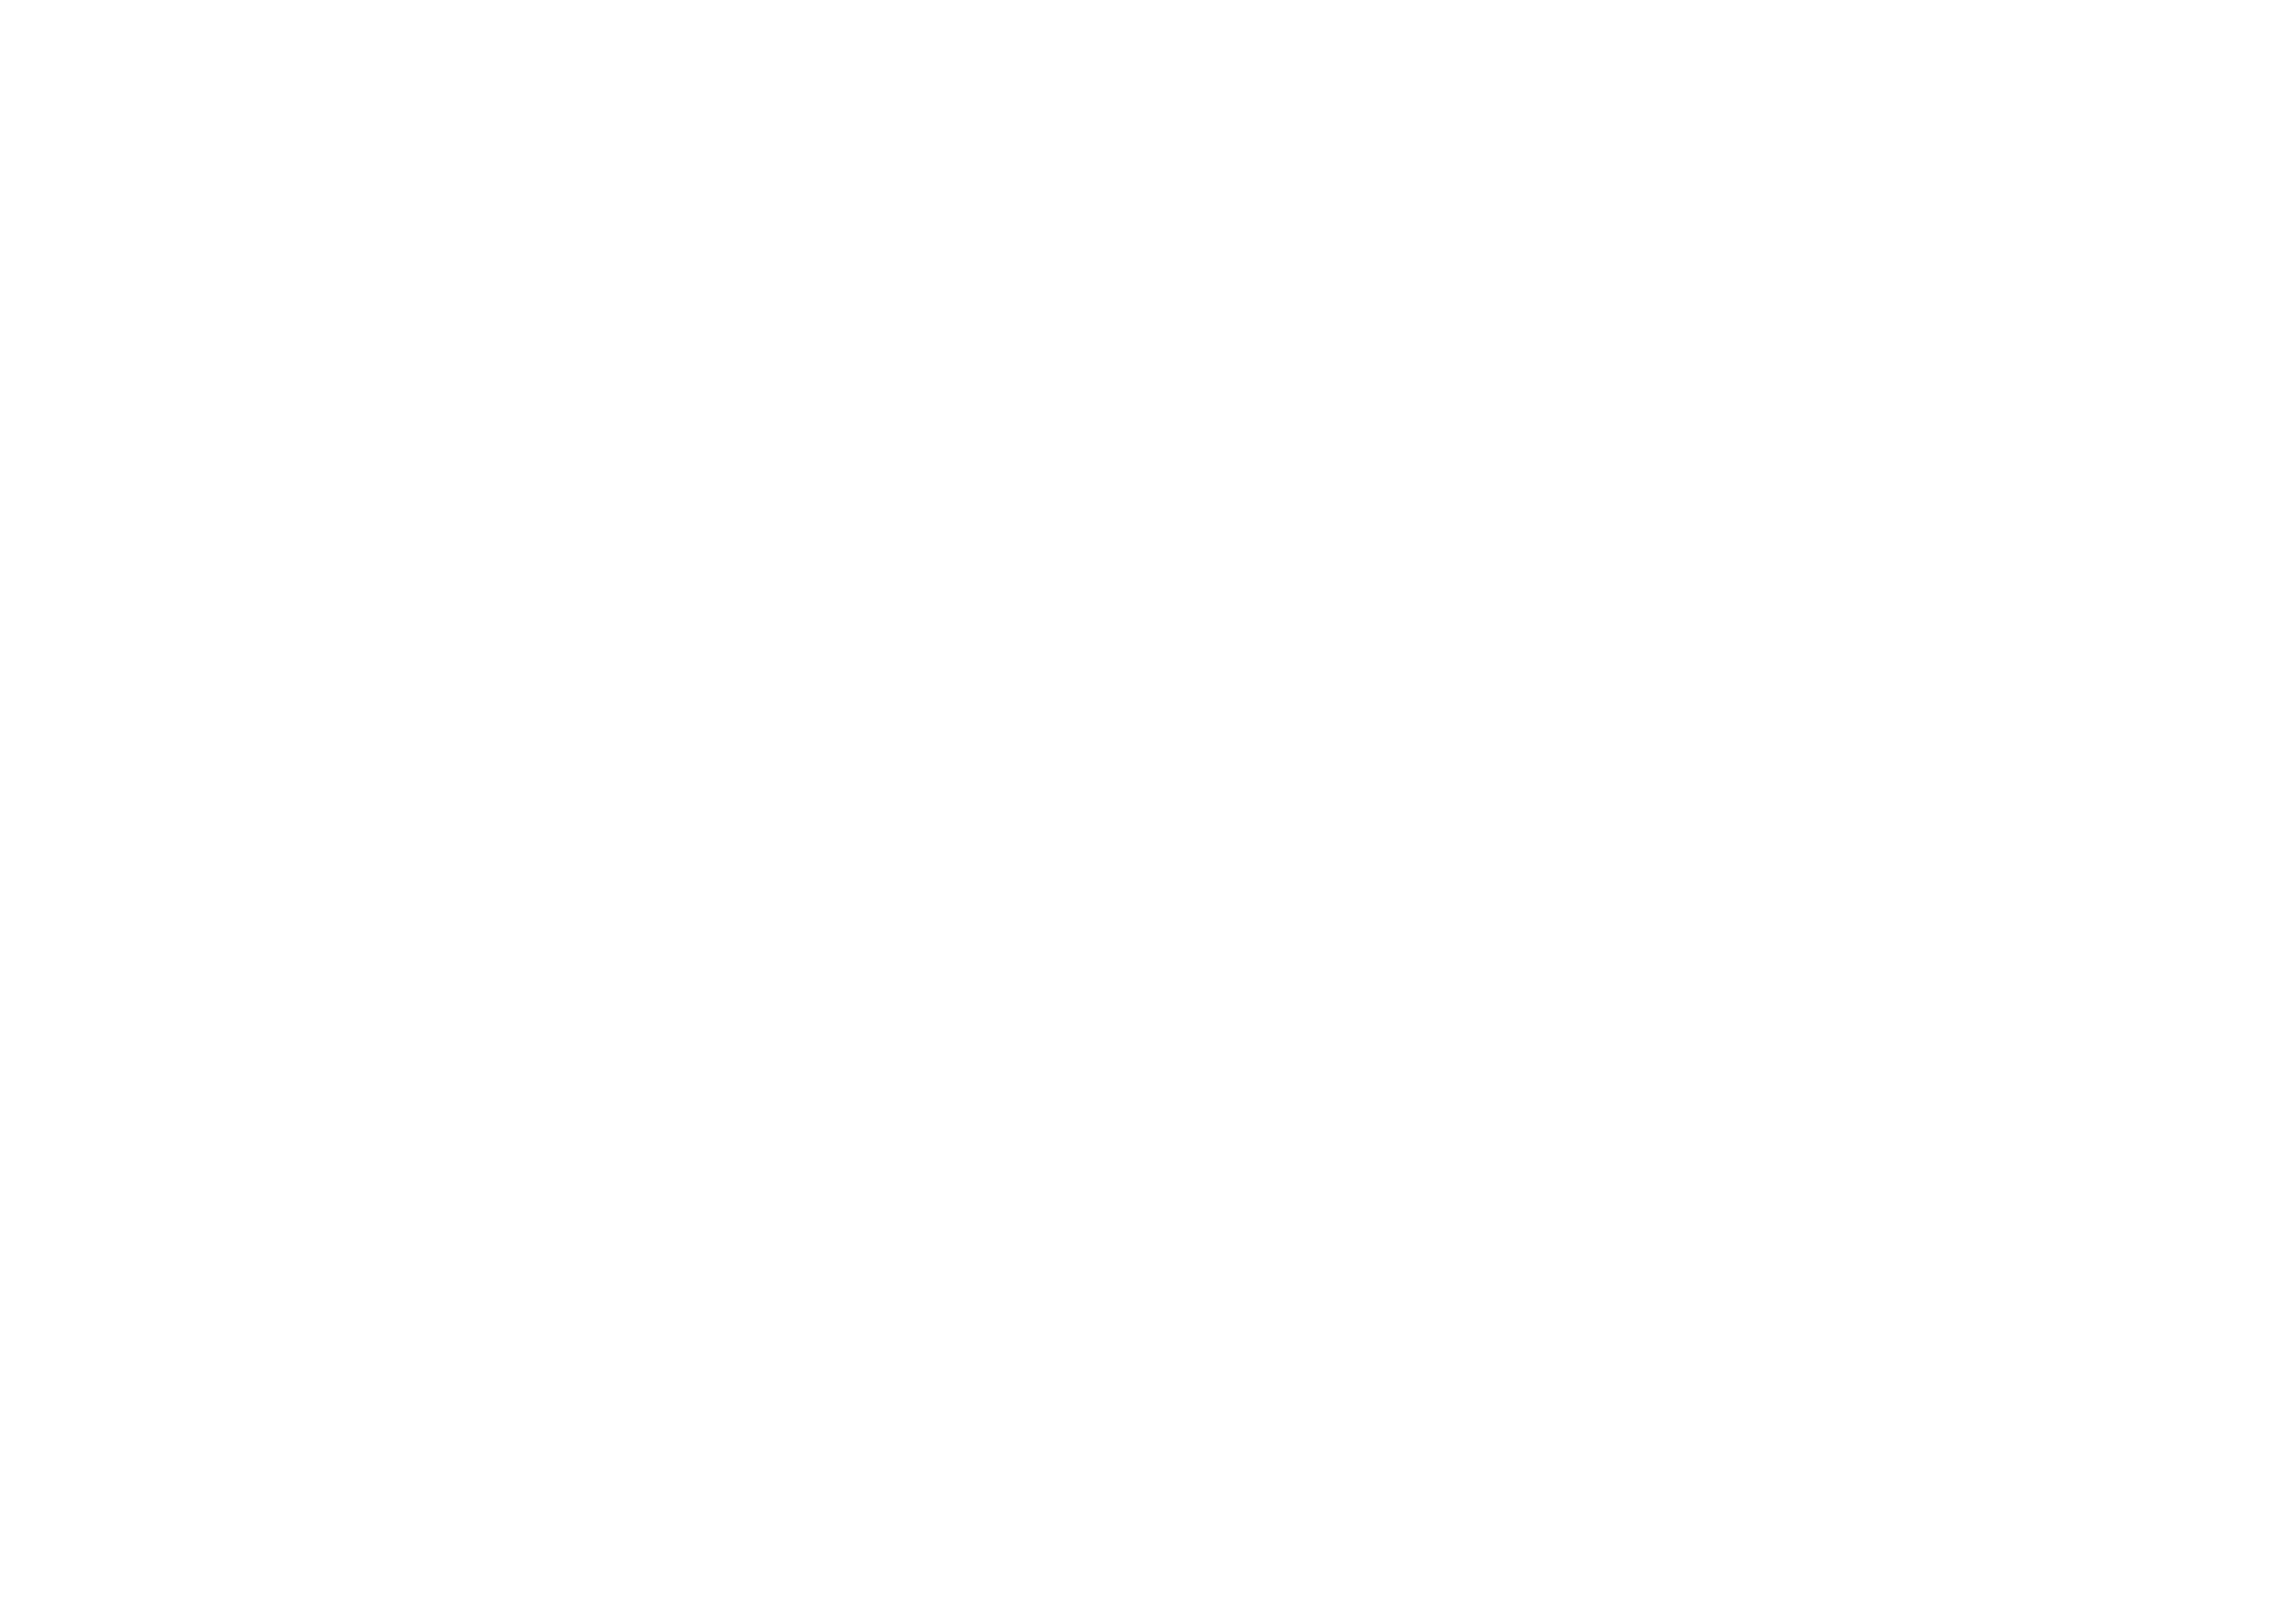

In [60]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
# Tạo biểu đồ
fig, ax = plt.subplots(figsize=(12, 8.5), dpi=300)
ax.axis('off')
ax.set_xlim(0, 1)
ax.set_ylim(-0.1, 1.15)
# Hàm vẽ Box (Khối hộp)
def draw_box(x, y, width, height, text, bg_color):
    # Vẽ khối hộp có góc bo tròn
    box = patches.FancyBboxPatch((x, y), width, height, 
                                 boxstyle="round,pad=0.03,rounding_size=0.02",
                                 fc=bg_color, ec="white", lw=2, zorder=3, alpha=0.95)
    ax.add_patch(box)
    # Ghi text vào giữa box
    ax.text(x + width/2, y + height/2, text, 
            ha='center', va='center', fontsize=13, fontweight='bold', 
            color='white', zorder=4, fontfamily='sans-serif')
# Hàm vẽ mũi tên kết nối
def draw_arrow(x1, y1, x2, y2):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(facecolor='#333333', edgecolor='#333333', 
                                arrowstyle="-|>,head_width=0.4,head_length=0.6", lw=2.5),
                zorder=2)
# ==============================================================
# BẮT ĐẦU VẼ KIẾN TRÚ

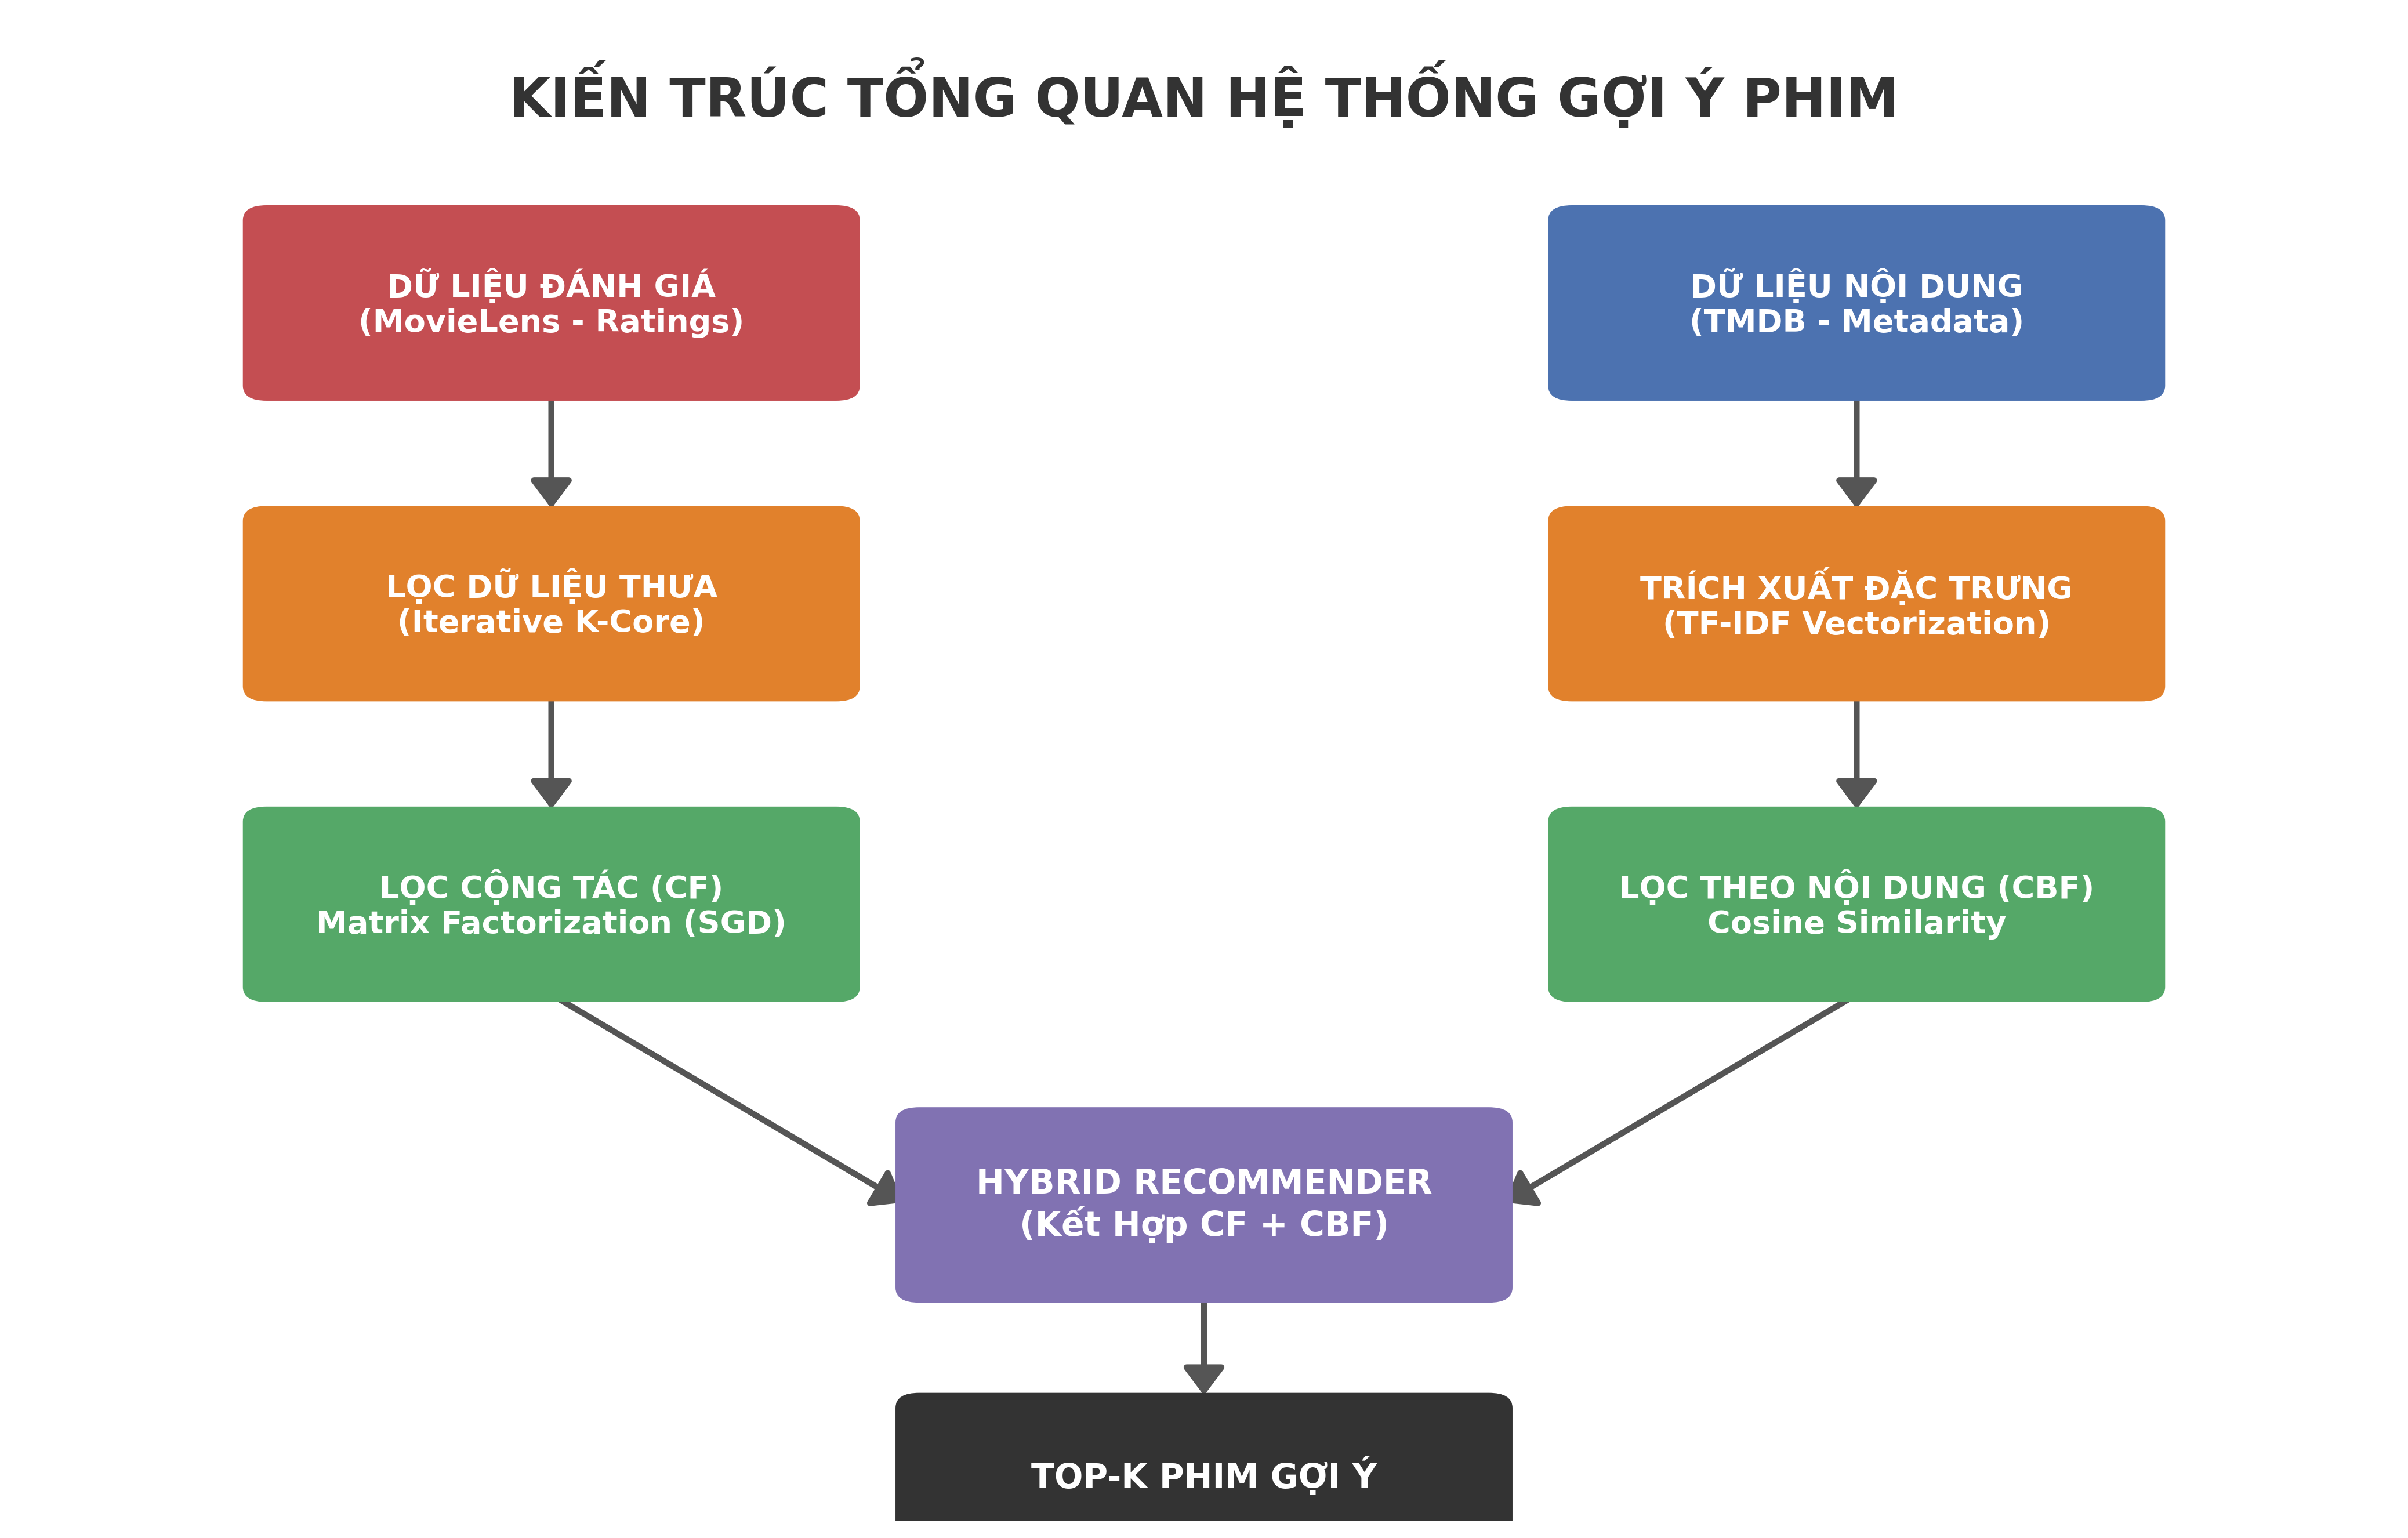

Đã vẽ và lưu ảnh kiến trúc thành công với tên: kien_truc_mo_hinh.png


In [61]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
# Tạo biểu đồ
fig, ax = plt.subplots(figsize=(14, 9), dpi=300)
ax.axis('off')
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
def draw_box(x, y, w, h, text, color, fontsize=12):
    # Vẽ khối hộp có góc bo tròn
    box = patches.FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.5,rounding_size=1",
                                 fc=color, ec='none', zorder=3)
    ax.add_patch(box)
    # Ghi text vào giữa box
    ax.text(x + w/2, y + h/2, text, ha='center', va='center', 
            fontsize=fontsize, fontweight='bold', color='white', zorder=4)
def draw_arrow(x1, y1, x2, y2):
    # Mũi tên kết nối các khối
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(facecolor='#555555', edgecolor='#555555', 
                                arrowstyle="-|>,head_width=0.6,head_length=0.8", lw=2.5),
                zorder=2)
# Tiêu đề biểu đồ
ax.text(50, 95, "KIẾN TRÚC TỔNG QUAN HỆ THỐNG GỢI Ý PHIM", ha='center', va='center', 
        fontsize=22, fontweight='bold', color='#333333')
# ==================== CÁC KHỐI CHÍNH ====================
# 1. Tầng Dữ Liệu (Data Sources)
draw_box(10, 75, 25, 12, "DỮ LIỆU ĐÁNH GIÁ\n(MovieLens - Ratings)", '#C44E52', 13)
draw_box(65, 75, 25, 12, "DỮ LIỆU NỘI DUNG\n(TMDB - Metadata)", '#4C72B0', 13)
# 2. Tầng Tiền Xử Lý (Preprocessing)
draw_box(10, 55, 25, 12, "LỌC DỮ LIỆU THƯA\n(Iterative K-Core)", '#E1812C', 13)
draw_box(65, 55, 25, 12, "TRÍCH XUẤT ĐẶC TRƯNG\n(TF-IDF Vectorization)", '#E1812C', 13)
# 3. Tầng Mô Hình (Models)
draw_box(10, 35, 25, 12, "LỌC CỘNG TÁC (CF)\nMatrix Factorization (SGD)", '#55A868', 13)
draw_box(65, 35, 25, 12, "LỌC THEO NỘI DUNG (CBF)\nCosine Similarity", '#55A868', 13)
# 4. Tầng Kết Hợp (Hybrid)
draw_box(37.5, 15, 25, 12, "HYBRID RECOMMENDER\n(Kết Hợp CF + CBF)", '#8172B2', 14)
# 5. Tầng Đầu Ra (Output)
draw_box(37.5, -2, 25, 10, "TOP-K PHIM GỢI Ý", '#333333', 14)
# ==================== KẾT NỐI MŨI TÊN ====================
# Nhánh bên trái (Lọc cộng tác - CF)
draw_arrow(22.5, 75, 22.5, 67) # Data -> Preprocess
draw_arrow(22.5, 55, 22.5, 47) # Preprocess -> Model
draw_arrow(22.5, 35, 37.5, 21) # Model -> Hybrid
# Nhánh bên phải (Lọc nội dung - CBF)
draw_arrow(77.5, 75, 77.5, 67) # Data -> Preprocess
draw_arrow(77.5, 55, 77.5, 47) # Preprocess -> Model
draw_arrow(77.5, 35, 62.5, 21) # Model -> Hybrid
# Đầu ra cuối cùng
draw_arrow(50, 15, 50, 8) 
# Lưu ảnh và hiển thị
plt.tight_layout()
plt.savefig('kien_truc_mo_hinh.png', bbox_inches='tight', dpi=300, transparent=False)
plt.show()
print("Đã vẽ và lưu ảnh kiến trúc thành công với tên: kien_truc_mo_hinh.png")